# Análisis de factores asociados a la aprobación en el sistema educativo colombiano

### 1. Objetivo del estudio:

Este proyecto busca aplicar los conceptos de la asignatura Modelos Lineales (prof. Juan Alejandro Trujillo Posada) a un caso real: modelar indicadores educativos municipales en Colombia. El reto principal radica en adaptar el modelo lineal múltiple a datos observacionales, lo que implica realizar un diagnóstico cuidadoso de supuestos, seleccionar variables con criterio estadístico y documentar las decisiones metodológicas para garantizar la validez de las inferencias.

-------------------------------------------------------------------------

### 2. Fuentes de los datos:
Los datos utilizados provienen de una fuente oficial del gobierno colombiano:

Sistema Nacional de Información del Ministerio de Educación
Disponible en:
- https://www.datos.gov.co/Educaci-n/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR-B-SICA/nudc-7mev/about_data

Estos datos incluyen información real sobre:

- Aprobación
- Reprobación
- Deserción
- Repitencia
- Cobertura
- Matrícula
- Población en edad escolar

------------------------------------------------------------------------------------

#### Primero se cargaron las librerias necesarias para la preparacion, transformacion y creacion del modelo

In [371]:
# Primero cargamos las librerias que vamos a utilizar
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from pandas import read_csv
from pandas import DataFrame
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import pickle
from scipy.stats import jarque_bera

In [372]:
# primero cargamos los datos
df = pd.read_csv(r'/home/diego-giraldo/Documentos/Umanizales/Proyectos/modelos_lineales/modelos_lineales/EDUCACION.csv')
df.head()

,AÑO,CÓDIGO_MUNICIPIO,MUNICIPIO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,CÓDIGO_ETC,ETC,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,...,REPROBACIÓN,REPROBACIÓN_TRANSICIÓN,REPROBACIÓN_PRIMARIA,REPROBACIÓN_SECUNDARIA,REPROBACIÓN_MEDIA,REPITENCIA,REPITENCIA_TRANSICIÓN,REPITENCIA_PRIMARIA,REPITENCIA_SECUNDARIA,REPITENCIA_MEDIA
0,2024,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),499,"56,11%","56,11%",...,"0,32%",0%,0%,0%,"2,33%","8,41%",0%,"8,51%",13%,"2,33%"
1,2024,15204,Cómbita,15,Boyacá,3769.0,Boyacá (ETC),1862,"95,33%","95,33%",...,"2,62%",0%,"1,71%","4,4%","1,05%","7,94%","1,69%","4,94%","14,53%",0%
2,2024,99773,Cumaribo,99,Vichada,3832.0,Vichada (ETC),25239,"50,7%","50,7%",...,"15,22%",0%,"20,39%","8,09%","5,7%","20,14%","0,63%","26,99%","11,05%","4,34%"
3,2024,99624,Santa Rosalía,99,Vichada,3832.0,Vichada (ETC),1157,"81,42%","81,42%",...,"7,63%",0%,"7,12%","10,92%","5,43%","13,17%",0%,15%,"16,67%","2,17%"
4,2024,99524,La Primavera,99,Vichada,3832.0,Vichada (ETC),2645,"90,96%","90,96%",...,"8,83%",0%,11%,"8,84%","2,91%","13,15%","0,68%","17,38%","11,67%","3,64%"


---------------------------------------------

# Transformacion de datos

En esta sección se realizó la preparación de los datos con el fin de poder analizarlos de manera correcta al ver los datos originales contienen información de distintas variables del sistema educativo, pero no estan listos directamente para construir un modelo lo que se planea hacer son varios ajustes como la organización de las columnas, la eliminación de posibles inconsistencias y el uso de valores promedio en algunas variables. esto ayudara a simplificar la información y evitar duplicidad de datos, el objetivo principal de este paso fue dejar un conjunto de datos limpio, claro y fácil de trabajar, asegurando que los resultados posteriores fueran confiables.

------------------------------------------------

In [373]:
# Debemos mirar el contenido de nuestros datos para entender que tipo de información tenemos y como podemos utilizarla para entrenar nuestro modelo de regresión logística. Para esto, podemos usar el método `info()` de pandas para obtener un resumen de las columnas, sus tipos de datos y la cantidad de valores no nulos.
# Ver dimensiones y columnas
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print("\nColumnas disponibles:")
print(df.columns.tolist())

# Ver primeras filas y tipos de datos
print("\nPrimeras 2 filas:")
print(df.head(2))
print("\nTipos de datos:")
print(df.dtypes)

Filas: 15707, Columnas: 41

Columnas disponibles:
['AÑO', 'CÓDIGO_MUNICIPIO', 'MUNICIPIO', 'CÓDIGO_DEPARTAMENTO', 'DEPARTAMENTO', 'CÓDIGO_ETC', 'ETC', 'POBLACIÓN_5_16', 'TASA_MATRICULACIÓN_5_16', 'COBERTURA_NETA', 'COBERTURA_NETA_TRANSICIÓN', 'COBERTURA_NETA_PRIMARIA', 'COBERTURA_NETA_SECUNDARIA', 'COBERTURA_NETA_MEDIA', 'COBERTURA_BRUTA', 'COBERTURA_BRUTA_TRANSICIÓN', 'COBERTURA_BRUTA_PRIMARIA', 'COBERTURA_BRUTA_SECUNDARIA', 'COBERTURA_BRUTA_MEDIA', 'TAMAÑO_PROMEDIO_DE_GRUPO', 'SEDES_CONECTADAS_A_INTERNET', 'DESERCIÓN', 'DESERCIÓN_TRANSICIÓN', 'DESERCIÓN_PRIMARIA', 'DESERCIÓN_SECUNDARIA', 'DESERCIÓN_MEDIA', 'APROBACIÓN', 'APROBACIÓN_TRANSICIÓN', 'APROBACIÓN_PRIMARIA', 'APROBACIÓN_SECUNDARIA', 'APROBACIÓN_MEDIA', 'REPROBACIÓN', 'REPROBACIÓN_TRANSICIÓN', 'REPROBACIÓN_PRIMARIA', 'REPROBACIÓN_SECUNDARIA', 'REPROBACIÓN_MEDIA', 'REPITENCIA', 'REPITENCIA_TRANSICIÓN', 'REPITENCIA_PRIMARIA', 'REPITENCIA_SECUNDARIA', 'REPITENCIA_MEDIA']

Primeras 2 filas:
    AÑO  CÓDIGO_MUNICIPIO MUNICIPIO  CÓ

-------------------------------

Transformamos todos las columnas que tienen ejemplo 56,11% a decimal 0.5611

-------------------------------

In [374]:

# para esto, podemos usar el método `apply()` de pandas junto con una función personalizada que convierta los valores de porcentaje a decimal. Aquí vamos a realizarlo:

def porcentaje_a_decimal(valor):
    if isinstance(valor, str):
        # Reemplazar coma por punto para el formato decimal
        valor_limpio = valor.replace(',', '.')
        # Si termina con %, lo convertimos a decimal
        if valor_limpio.endswith('%'):
            return float(valor_limpio.strip('%')) / 100
        else:
            # Si no es porcentaje pero tiene coma, lo convertimos a float
            try:
                return float(valor_limpio)
            except ValueError:
                return valor
    elif isinstance(valor, (int, float)):
        return valor
    else:
        return valor

# Identificamos las columnas que contienen porcentajes (terminan con %)
percentage_columns = []
for col in df.columns:
    # Verificamos si alguna muestra de datos en la columna contiene %
    sample_values = df[col].dropna().head(10)  # Tomamos algunas muestras
    has_percentage = sample_values.astype(str).str.contains('%', na=False).any()
    if has_percentage:
        percentage_columns.append(col)

print("Columnas con porcentajes identificadas:", percentage_columns)

# Aplicamos la función solo a las columnas que contienen porcentajes
for col in percentage_columns:
    df[col] = df[col].apply(porcentaje_a_decimal)

Columnas con porcentajes identificadas: ['TASA_MATRICULACIÓN_5_16', 'COBERTURA_NETA', 'COBERTURA_NETA_TRANSICIÓN', 'COBERTURA_NETA_PRIMARIA', 'COBERTURA_NETA_SECUNDARIA', 'COBERTURA_NETA_MEDIA', 'COBERTURA_BRUTA', 'COBERTURA_BRUTA_TRANSICIÓN', 'COBERTURA_BRUTA_PRIMARIA', 'COBERTURA_BRUTA_SECUNDARIA', 'COBERTURA_BRUTA_MEDIA', 'TAMAÑO_PROMEDIO_DE_GRUPO', 'SEDES_CONECTADAS_A_INTERNET', 'DESERCIÓN', 'DESERCIÓN_TRANSICIÓN', 'DESERCIÓN_PRIMARIA', 'DESERCIÓN_SECUNDARIA', 'DESERCIÓN_MEDIA', 'APROBACIÓN', 'APROBACIÓN_TRANSICIÓN', 'APROBACIÓN_PRIMARIA', 'APROBACIÓN_SECUNDARIA', 'APROBACIÓN_MEDIA', 'REPROBACIÓN', 'REPROBACIÓN_TRANSICIÓN', 'REPROBACIÓN_PRIMARIA', 'REPROBACIÓN_SECUNDARIA', 'REPROBACIÓN_MEDIA', 'REPITENCIA', 'REPITENCIA_TRANSICIÓN', 'REPITENCIA_PRIMARIA', 'REPITENCIA_SECUNDARIA', 'REPITENCIA_MEDIA']


In [375]:
# verificamos que columnas cambiaron de manera correcta
print("\nTipos de datos después de la conversión:")
print(df.dtypes)


Tipos de datos después de la conversión:
AÑO                              int64
CÓDIGO_MUNICIPIO                 int64
MUNICIPIO                          str
CÓDIGO_DEPARTAMENTO              int64
DEPARTAMENTO                       str
CÓDIGO_ETC                     float64
ETC                                str
POBLACIÓN_5_16                     str
TASA_MATRICULACIÓN_5_16        float64
COBERTURA_NETA                 float64
COBERTURA_NETA_TRANSICIÓN      float64
COBERTURA_NETA_PRIMARIA        float64
COBERTURA_NETA_SECUNDARIA      float64
COBERTURA_NETA_MEDIA           float64
COBERTURA_BRUTA                float64
COBERTURA_BRUTA_TRANSICIÓN     float64
COBERTURA_BRUTA_PRIMARIA       float64
COBERTURA_BRUTA_SECUNDARIA     float64
COBERTURA_BRUTA_MEDIA          float64
TAMAÑO_PROMEDIO_DE_GRUPO       float64
SEDES_CONECTADAS_A_INTERNET    float64
DESERCIÓN                      float64
DESERCIÓN_TRANSICIÓN           float64
DESERCIÓN_PRIMARIA             float64
DESERCIÓN_SECUNDARIA  

----------------------------------------------------------------

Ahora eliminamos columnas que no son necesarias para el modelo, como 'CÓDIGO_MUNICIPIO' y 'ETC', ya que no aportan información relevante para la predicción de la variable objetivo.

-----------------------------------------------------------------

In [376]:
# Primero verificamos qué columnas existen realmente
print("Columnas actuales:", df.columns.tolist())
existing_columns_to_drop = [col for col in ['MUNICIPIO', 'ETC', 'CÓDIGO_ETC', 'DEPARTAMENTO', 'AÑO'] if col in df.columns]
print("Columnas a eliminar:", existing_columns_to_drop)

if existing_columns_to_drop:
	df = df.drop(columns=existing_columns_to_drop)
else:
	print("No se encontraron columnas para eliminar")

print("\nColumnas después de eliminar las no necesarias:")
print(df.columns.tolist())

Columnas actuales: ['AÑO', 'CÓDIGO_MUNICIPIO', 'MUNICIPIO', 'CÓDIGO_DEPARTAMENTO', 'DEPARTAMENTO', 'CÓDIGO_ETC', 'ETC', 'POBLACIÓN_5_16', 'TASA_MATRICULACIÓN_5_16', 'COBERTURA_NETA', 'COBERTURA_NETA_TRANSICIÓN', 'COBERTURA_NETA_PRIMARIA', 'COBERTURA_NETA_SECUNDARIA', 'COBERTURA_NETA_MEDIA', 'COBERTURA_BRUTA', 'COBERTURA_BRUTA_TRANSICIÓN', 'COBERTURA_BRUTA_PRIMARIA', 'COBERTURA_BRUTA_SECUNDARIA', 'COBERTURA_BRUTA_MEDIA', 'TAMAÑO_PROMEDIO_DE_GRUPO', 'SEDES_CONECTADAS_A_INTERNET', 'DESERCIÓN', 'DESERCIÓN_TRANSICIÓN', 'DESERCIÓN_PRIMARIA', 'DESERCIÓN_SECUNDARIA', 'DESERCIÓN_MEDIA', 'APROBACIÓN', 'APROBACIÓN_TRANSICIÓN', 'APROBACIÓN_PRIMARIA', 'APROBACIÓN_SECUNDARIA', 'APROBACIÓN_MEDIA', 'REPROBACIÓN', 'REPROBACIÓN_TRANSICIÓN', 'REPROBACIÓN_PRIMARIA', 'REPROBACIÓN_SECUNDARIA', 'REPROBACIÓN_MEDIA', 'REPITENCIA', 'REPITENCIA_TRANSICIÓN', 'REPITENCIA_PRIMARIA', 'REPITENCIA_SECUNDARIA', 'REPITENCIA_MEDIA']
Columnas a eliminar: ['MUNICIPIO', 'ETC', 'CÓDIGO_ETC', 'DEPARTAMENTO', 'AÑO']

Columnas 

----------------------------------------------------------------------

Identificamos las columnas que son de tipo object (string) y verificamos si podemos convertirlas a numéricas. En este caso, parece que no hay columnas de tipo object, lo que indica que todas las columnas ya están en un formato numérico adecuado para el análisis.

----------------------------------------------------------------------

In [377]:

# Sin embargo, si hubiera columnas de tipo object, podríamos intentar convertirlas a numéricas utilizando técnicas como el encoding o la conversión directa, dependiendo del contexto de los datos. En este caso, no es necesario realizar ninguna conversión adicional.

columnas_object = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nColumnas de tipo object: {columnas_object}")




Columnas de tipo object: ['POBLACIÓN_5_16']


In [378]:
# Vemos la informacion de ['POBLACIÓN_5_16', 'TAMAÑO_PROMEDIO_DE_GRUPO', 'SEDES_CONECTADAS_A_INTERNET']
print("\nInformación de las columnas seleccionadas:")
print(df[['POBLACIÓN_5_16', 'TAMAÑO_PROMEDIO_DE_GRUPO', 'SEDES_CONECTADAS_A_INTERNET']].describe())



Información de las columnas seleccionadas:
       TAMAÑO_PROMEDIO_DE_GRUPO  SEDES_CONECTADAS_A_INTERNET
count               7572.000000                  7768.000000
mean                   0.239522                     0.348314
std                    0.077042                     0.261835
min                    0.030000                     0.000000
25%                    0.194298                     0.142900
50%                    0.239600                     0.281300
75%                    0.278402                     0.500000
max                    0.540300                     1.000000


In [379]:
# convertimos a numericos las columnas ['POBLACIÓN_5_16', 'TAMAÑO_PROMEDIO_DE_GRUPO', 'SEDES_CONECTADAS_A_INTERNET'] a numericas
df['POBLACIÓN_5_16'] = pd.to_numeric(df['POBLACIÓN_5_16'], errors='coerce')
df['TAMAÑO_PROMEDIO_DE_GRUPO'] = pd.to_numeric(df['TAMAÑO_PROMEDIO_DE_GRUPO'], errors='coerce')
df['SEDES_CONECTADAS_A_INTERNET'] = pd.to_numeric(df['SEDES_CONECTADAS_A_INTERNET'], errors='coerce') 

print(df[['POBLACIÓN_5_16', 'TAMAÑO_PROMEDIO_DE_GRUPO', 'SEDES_CONECTADAS_A_INTERNET']].describe())


       POBLACIÓN_5_16  TAMAÑO_PROMEDIO_DE_GRUPO  SEDES_CONECTADAS_A_INTERNET
count    1.570000e+04               7572.000000                  7768.000000
mean     1.006086e+04                  0.239522                     0.348314
std      1.387987e+05                  0.077042                     0.261835
min      1.000000e+00                  0.030000                     0.000000
25%      1.174000e+03                  0.194298                     0.142900
50%      2.655000e+03                  0.239600                     0.281300
75%      5.889250e+03                  0.278402                     0.500000
max      9.548263e+06                  0.540300                     1.000000


---------------------------------------------------------------

Se realizó un proceso de depuración eliminando observaciones con valores faltantes en las variables incluidas en el modelo (listwise deletion). Dado que el porcentaje de registros excluidos fue inferior al 6% y la muestra final (n ≈ 14,800) mantiene potencia estadística adecuada, se consideró que este enfoque preserva la validez de las estimaciones sin introducir sesgos por imputación. Variables con más del 50% de datos faltantes (TAMAÑO_PROMEDIO_DE_GRUPO, SEDES_CONECTADAS_A_INTERNET) fueron excluidas del análisis.

--------------------------------------------------------------

In [380]:
# Verificamos nan en las columnas de nuestro dataset
print("\nValores nulos en cada columna:")
print(df.isnull().sum())


Valores nulos en cada columna:
CÓDIGO_MUNICIPIO                  0
CÓDIGO_DEPARTAMENTO               0
POBLACIÓN_5_16                    7
TASA_MATRICULACIÓN_5_16         115
COBERTURA_NETA                  111
COBERTURA_NETA_TRANSICIÓN        52
COBERTURA_NETA_PRIMARIA          91
COBERTURA_NETA_SECUNDARIA        94
COBERTURA_NETA_MEDIA             93
COBERTURA_BRUTA                  68
COBERTURA_BRUTA_TRANSICIÓN       97
COBERTURA_BRUTA_PRIMARIA         81
COBERTURA_BRUTA_SECUNDARIA       88
COBERTURA_BRUTA_MEDIA           127
TAMAÑO_PROMEDIO_DE_GRUPO       8135
SEDES_CONECTADAS_A_INTERNET    7939
DESERCIÓN                       142
DESERCIÓN_TRANSICIÓN            903
DESERCIÓN_PRIMARIA              242
DESERCIÓN_SECUNDARIA            270
DESERCIÓN_MEDIA                 734
APROBACIÓN                       25
APROBACIÓN_TRANSICIÓN            93
APROBACIÓN_PRIMARIA              25
APROBACIÓN_SECUNDARIA            54
APROBACIÓN_MEDIA                101
REPROBACIÓN                     

# Exploracion de datos

---------------------------------------------------------------------

Tambien se realizó una revisión general de los datos con el fin de entender su comportamiento, al observar la información se analizaron los valores de cada variable, su distribución y cómo se relacionan entre sí, esto permitió identificar patrones, tendencias y posibles relaciones importantes entre los datos, este paso fue importante porque me permitió tener una visión clara del problema antes de construir el modelo, facilitando la toma de decisiones en las siguientes etapas.

-------------------------------------------------------------------

In [381]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 15707 entries, 0 to 15706
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CÓDIGO_MUNICIPIO             15707 non-null  int64  
 1   CÓDIGO_DEPARTAMENTO          15707 non-null  int64  
 2   POBLACIÓN_5_16               15700 non-null  float64
 3   TASA_MATRICULACIÓN_5_16      15592 non-null  float64
 4   COBERTURA_NETA               15596 non-null  float64
 5   COBERTURA_NETA_TRANSICIÓN    15655 non-null  float64
 6   COBERTURA_NETA_PRIMARIA      15616 non-null  float64
 7   COBERTURA_NETA_SECUNDARIA    15613 non-null  float64
 8   COBERTURA_NETA_MEDIA         15614 non-null  float64
 9   COBERTURA_BRUTA              15639 non-null  float64
 10  COBERTURA_BRUTA_TRANSICIÓN   15610 non-null  float64
 11  COBERTURA_BRUTA_PRIMARIA     15626 non-null  float64
 12  COBERTURA_BRUTA_SECUNDARIA   15619 non-null  float64
 13  COBERTURA_BRUTA_MEDIA      

,CÓDIGO_MUNICIPIO,CÓDIGO_DEPARTAMENTO,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,COBERTURA_NETA_TRANSICIÓN,COBERTURA_NETA_PRIMARIA,COBERTURA_NETA_SECUNDARIA,COBERTURA_NETA_MEDIA,COBERTURA_BRUTA,...,REPROBACIÓN,REPROBACIÓN_TRANSICIÓN,REPROBACIÓN_PRIMARIA,REPROBACIÓN_SECUNDARIA,REPROBACIÓN_MEDIA,REPITENCIA,REPITENCIA_TRANSICIÓN,REPITENCIA_PRIMARIA,REPITENCIA_SECUNDARIA,REPITENCIA_MEDIA
count,15707.000000,15707.000000,1.570000e+04,15592.000000,15596.000000,15655.000000,15616.000000,15613.000000,15614.000000,15639.000000,...,15621.000000,15614.000000,15610.000000,15601.000000,15562.000000,15564.000000,15548.000000,15559.000000,15555.000000,15568.000000
mean,38690.492137,38.256764,1.006086e+04,0.846911,0.852268,0.575506,0.822580,0.698424,0.409957,0.970253,...,0.048285,0.004822,0.039299,0.069521,0.041476,0.036755,0.011598,0.035277,0.048285,0.018421
std,26551.520074,26.564923,1.387987e+05,0.184202,0.168780,0.160977,0.171113,0.187037,0.156140,0.211757,...,0.039437,0.016421,0.037595,0.060981,0.041770,0.036103,0.028251,0.038972,0.048537,0.023651
min,0.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15676.000000,15.000000,1.174000e+03,0.745875,0.764200,0.474000,0.729000,0.603700,0.314025,0.850700,...,0.011800,0.000000,0.005800,0.010300,0.007425,0.008000,0.000000,0.006700,0.008500,0.000000
50%,25839.000000,25.000000,2.655000e+03,0.850200,0.860400,0.576700,0.825000,0.708000,0.414000,0.969600,...,0.046700,0.000000,0.034500,0.064000,0.031800,0.024600,0.000000,0.021500,0.031900,0.010200
75%,66572.000000,66.000000,5.889250e+03,0.950025,0.942700,0.677850,0.916000,0.804000,0.507000,1.086050,...,0.074300,0.002200,0.059900,0.109600,0.064000,0.057925,0.011800,0.053200,0.078300,0.028425
max,99773.000000,99.000000,9.548263e+06,2.790300,2.645400,1.504700,2.549600,2.294400,1.702600,2.869200,...,0.493900,0.527100,0.519700,0.769700,0.678600,0.374700,0.666700,0.507600,0.550700,0.368400



Columnas numéricas: ['CÓDIGO_MUNICIPIO', 'CÓDIGO_DEPARTAMENTO', 'POBLACIÓN_5_16', 'TASA_MATRICULACIÓN_5_16', 'COBERTURA_NETA', 'COBERTURA_NETA_TRANSICIÓN', 'COBERTURA_NETA_PRIMARIA', 'COBERTURA_NETA_SECUNDARIA', 'COBERTURA_NETA_MEDIA', 'COBERTURA_BRUTA', 'COBERTURA_BRUTA_TRANSICIÓN', 'COBERTURA_BRUTA_PRIMARIA', 'COBERTURA_BRUTA_SECUNDARIA', 'COBERTURA_BRUTA_MEDIA', 'TAMAÑO_PROMEDIO_DE_GRUPO', 'SEDES_CONECTADAS_A_INTERNET', 'DESERCIÓN', 'DESERCIÓN_TRANSICIÓN', 'DESERCIÓN_PRIMARIA', 'DESERCIÓN_SECUNDARIA', 'DESERCIÓN_MEDIA', 'APROBACIÓN', 'APROBACIÓN_TRANSICIÓN', 'APROBACIÓN_PRIMARIA', 'APROBACIÓN_SECUNDARIA', 'APROBACIÓN_MEDIA', 'REPROBACIÓN', 'REPROBACIÓN_TRANSICIÓN', 'REPROBACIÓN_PRIMARIA', 'REPROBACIÓN_SECUNDARIA', 'REPROBACIÓN_MEDIA', 'REPITENCIA', 'REPITENCIA_TRANSICIÓN', 'REPITENCIA_PRIMARIA', 'REPITENCIA_SECUNDARIA', 'REPITENCIA_MEDIA']


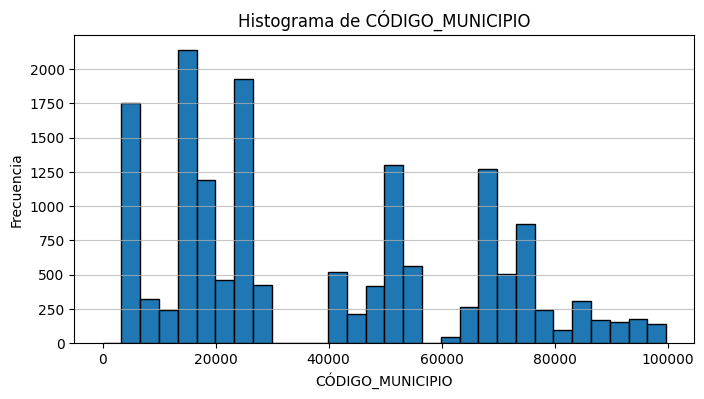

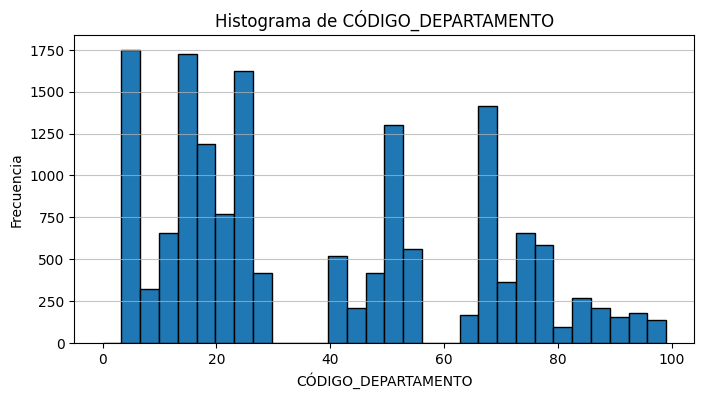

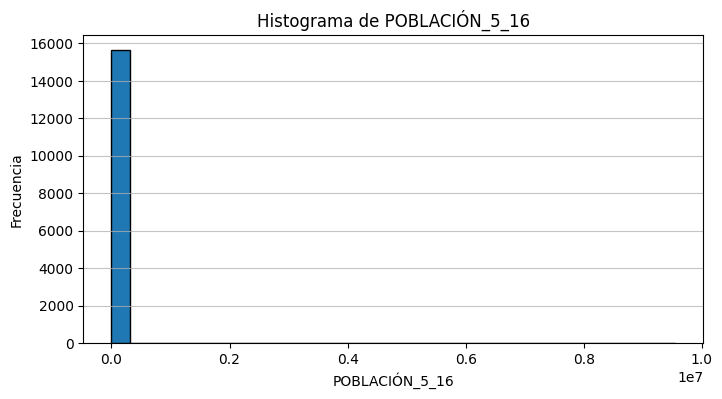

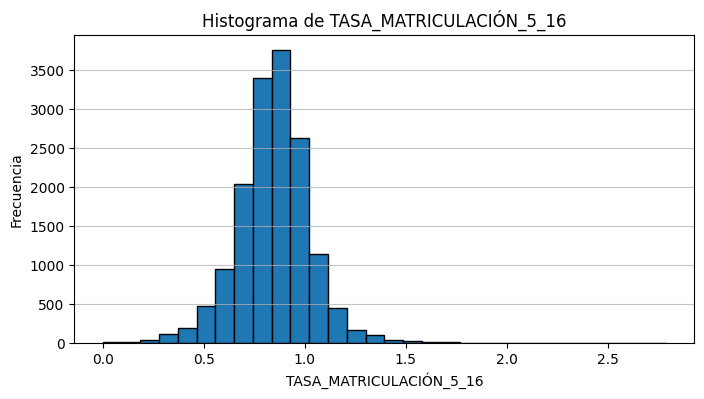

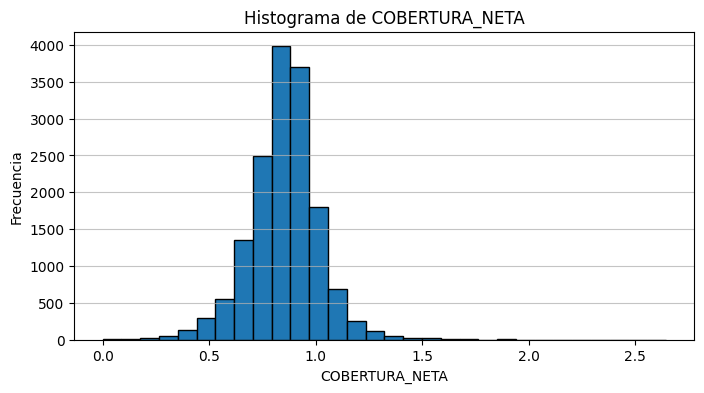

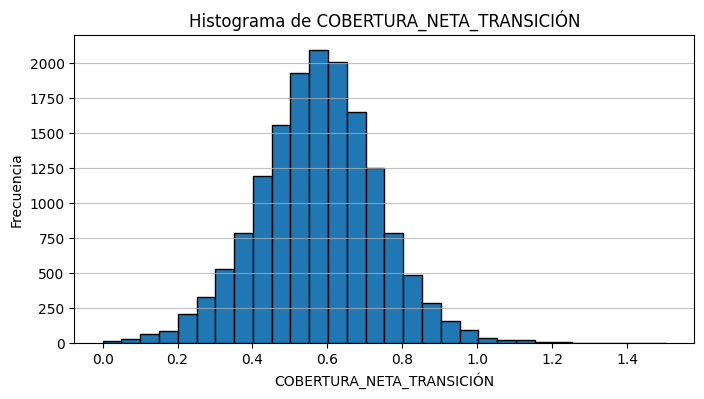

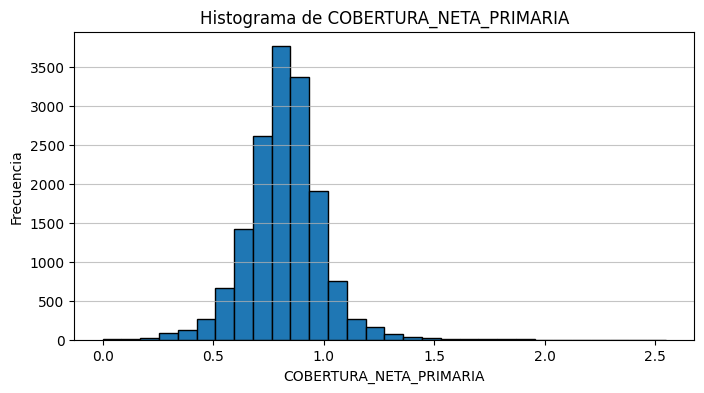

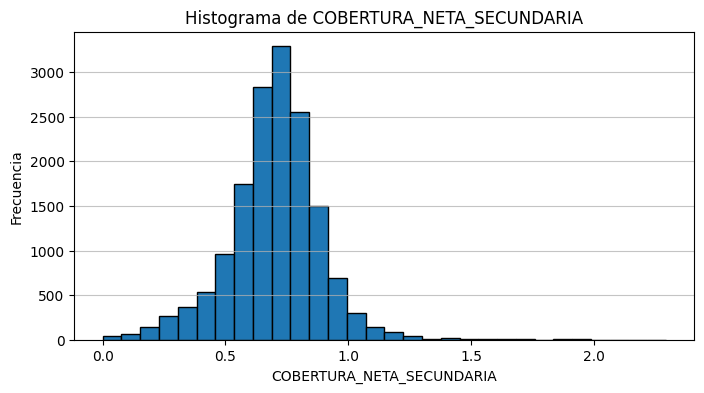

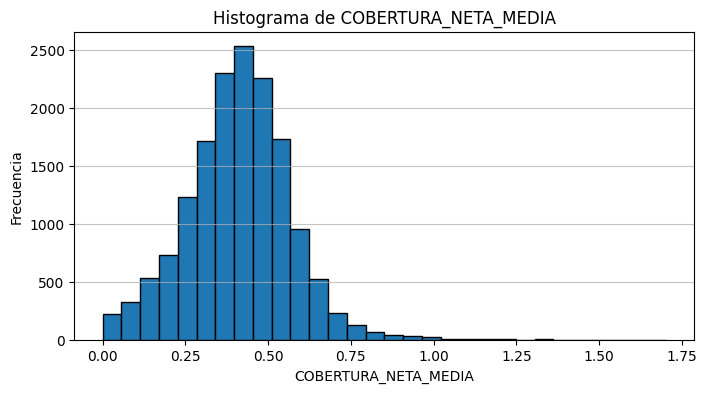

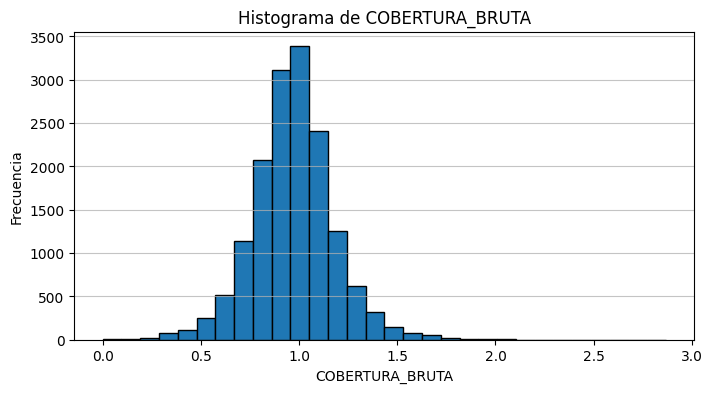

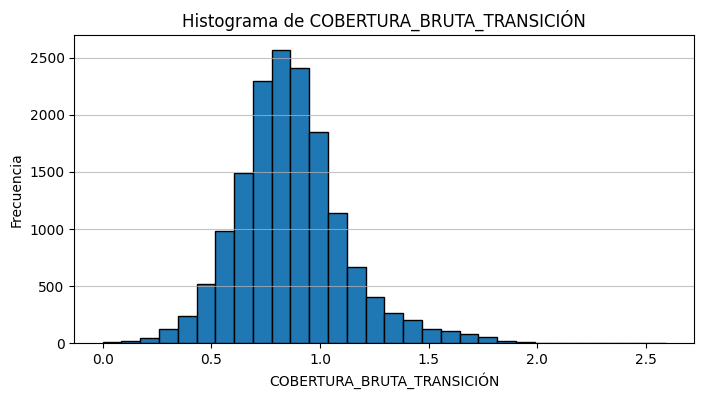

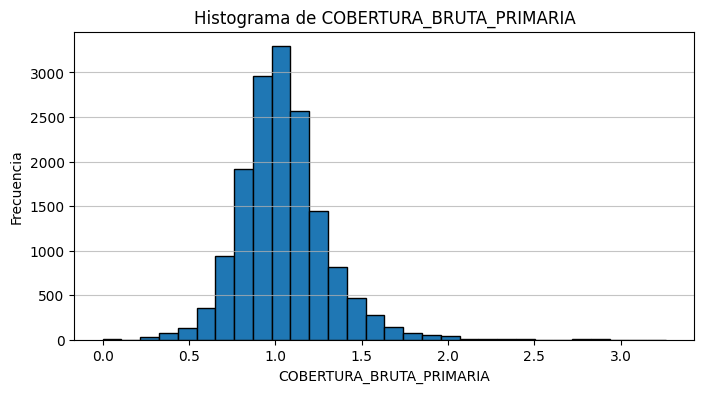

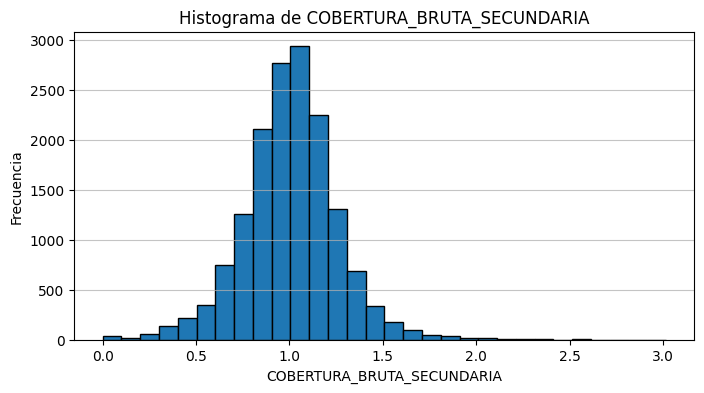

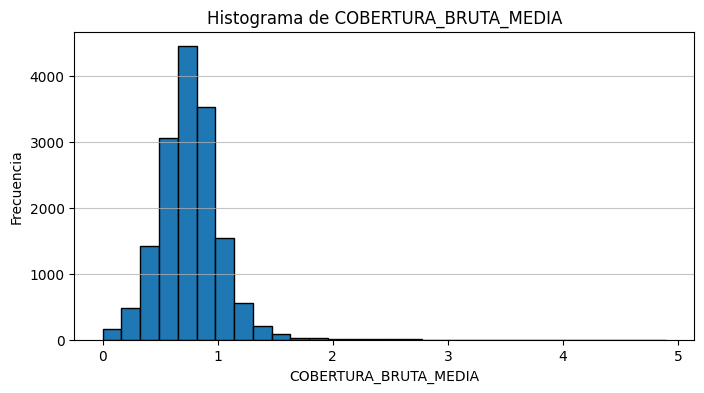

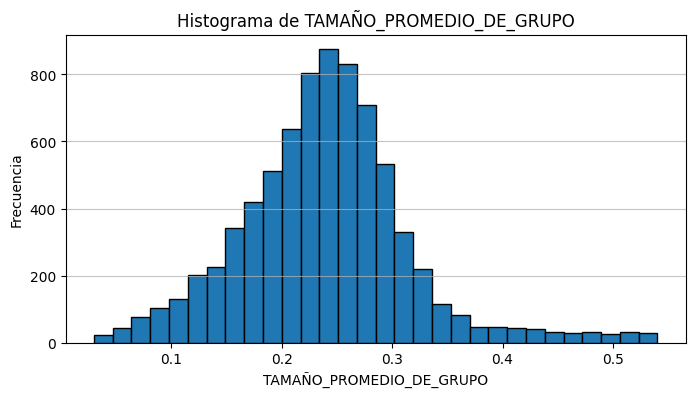

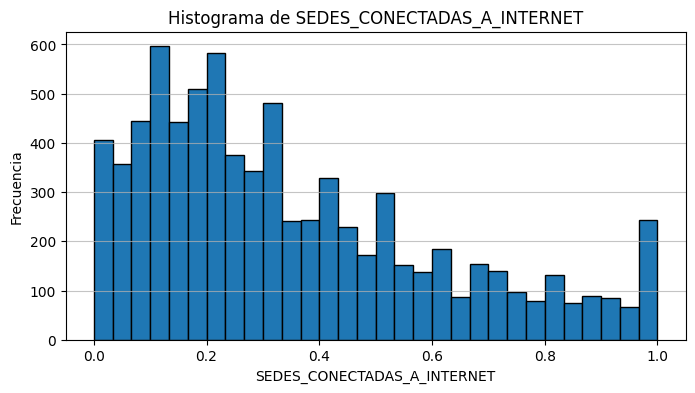

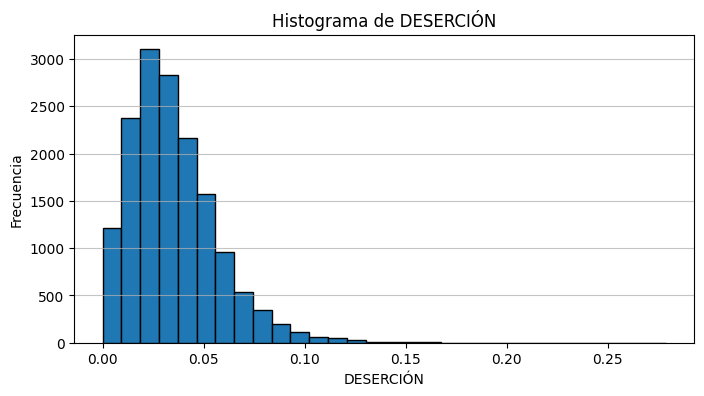

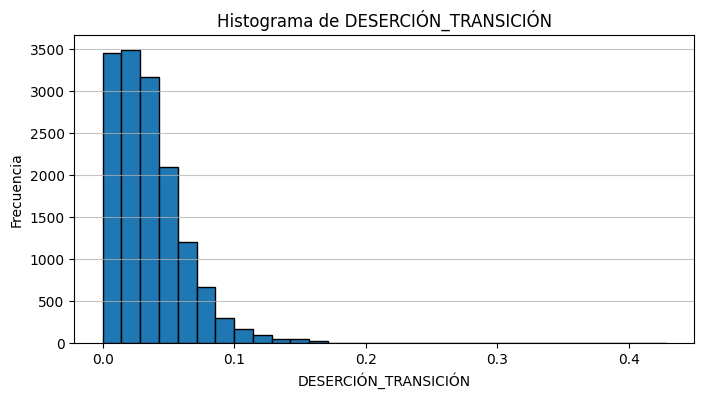

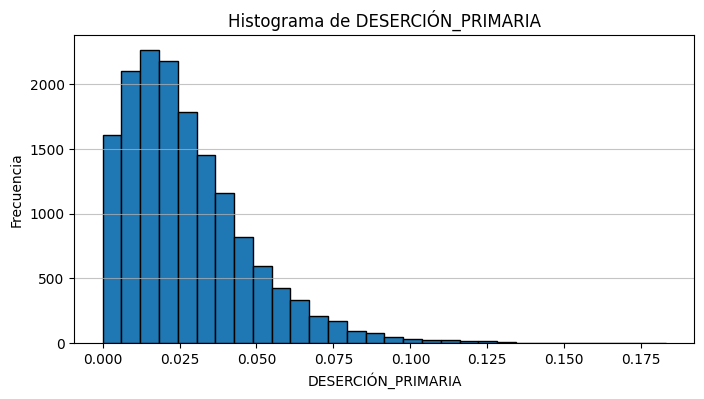

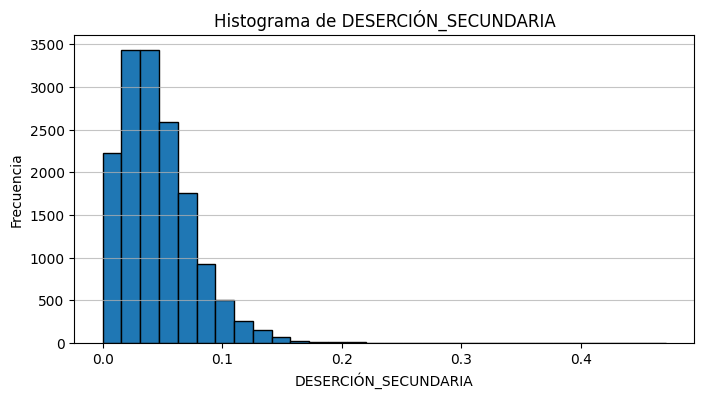

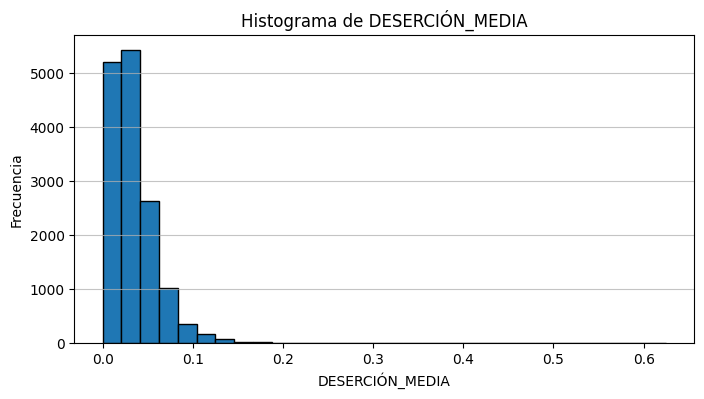

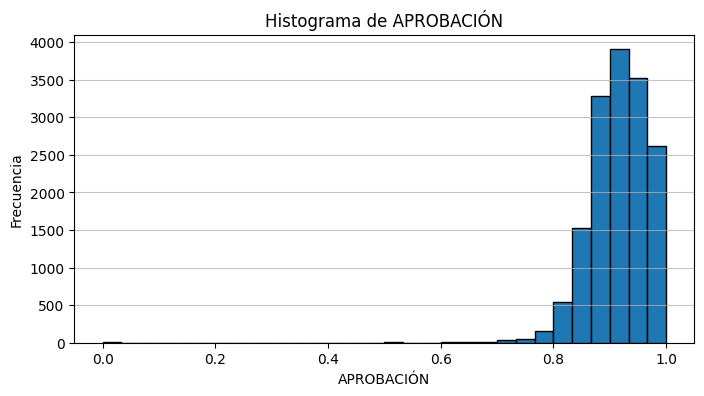

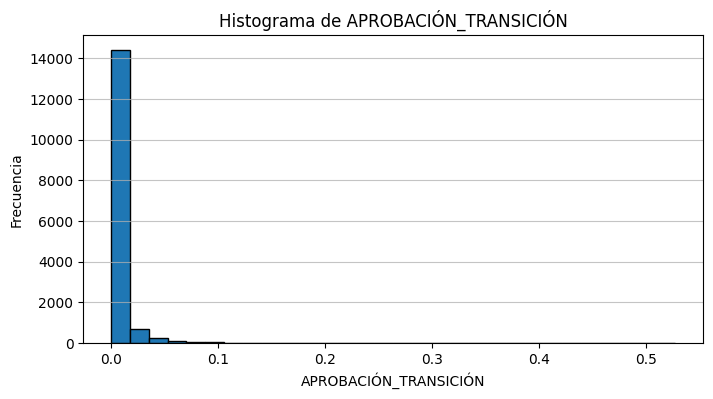

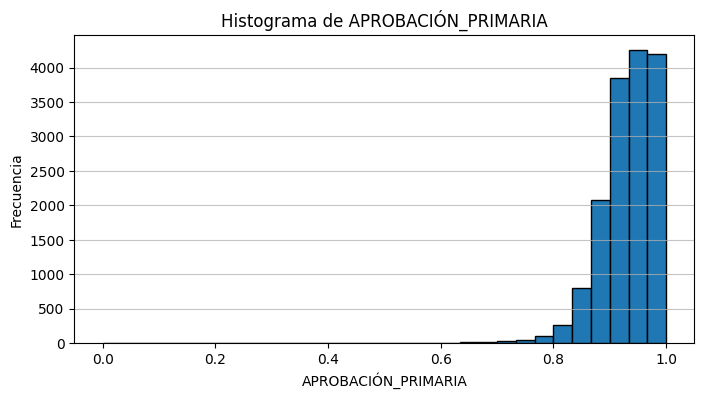

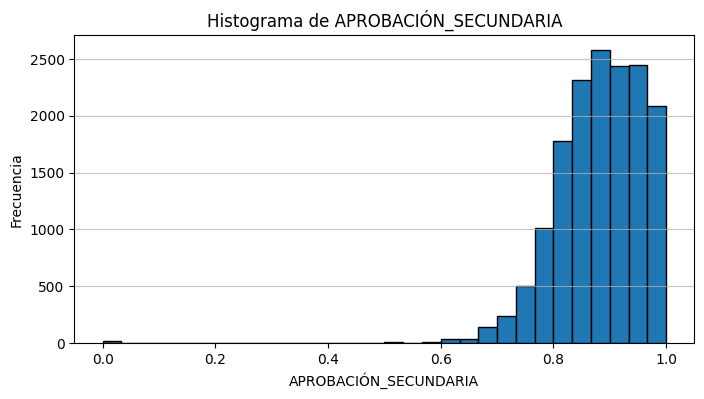

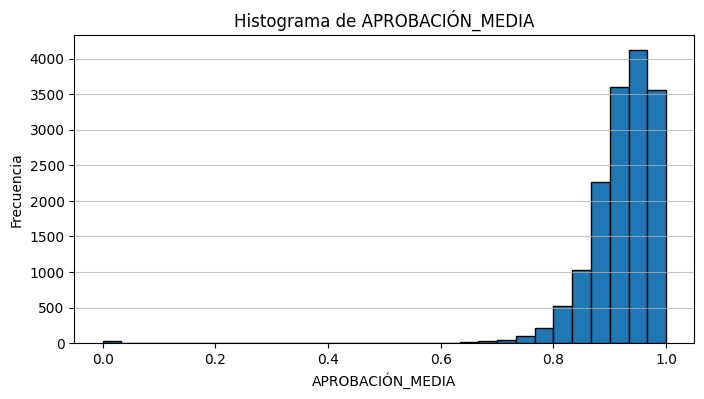

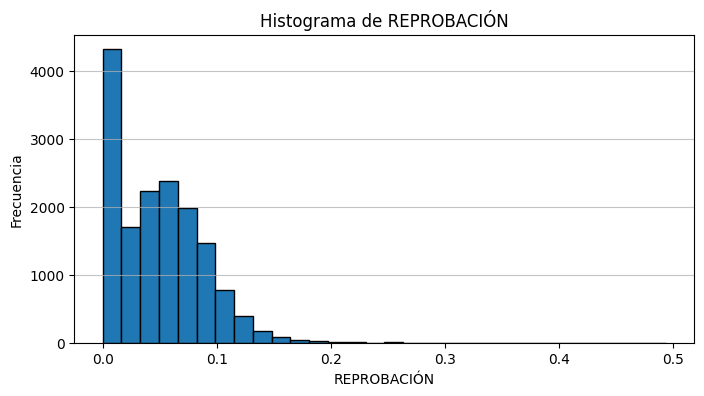

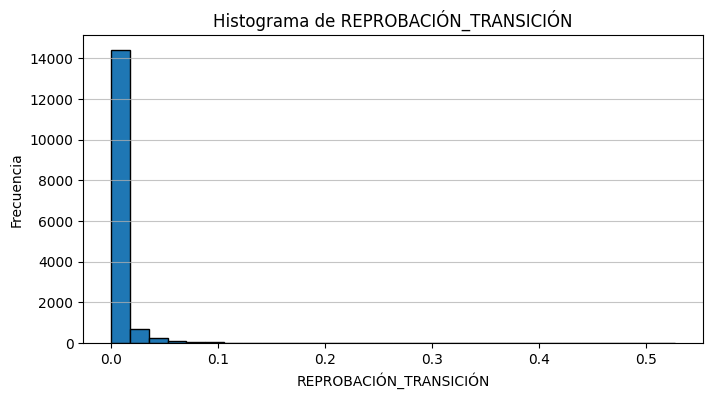

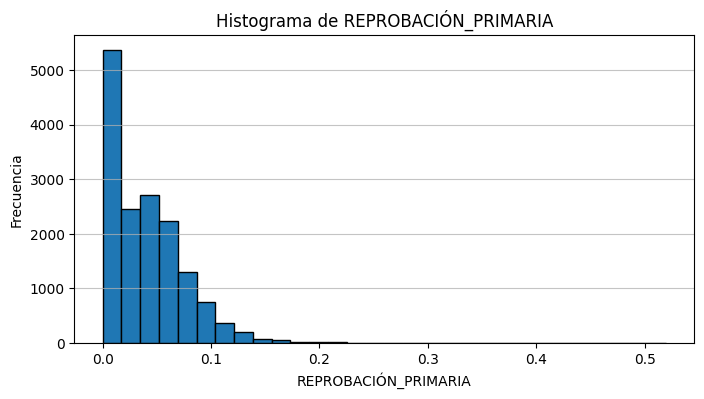

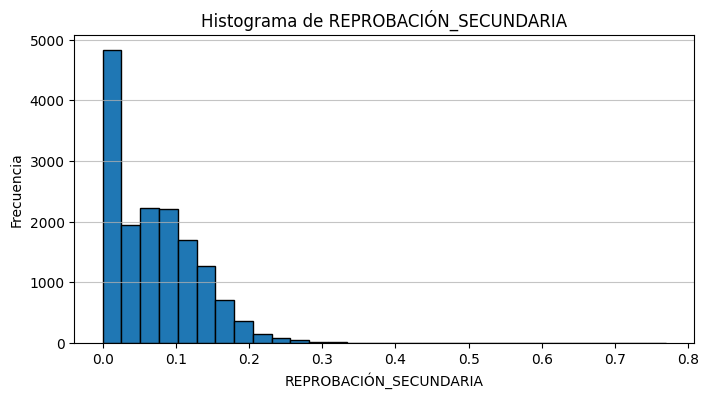

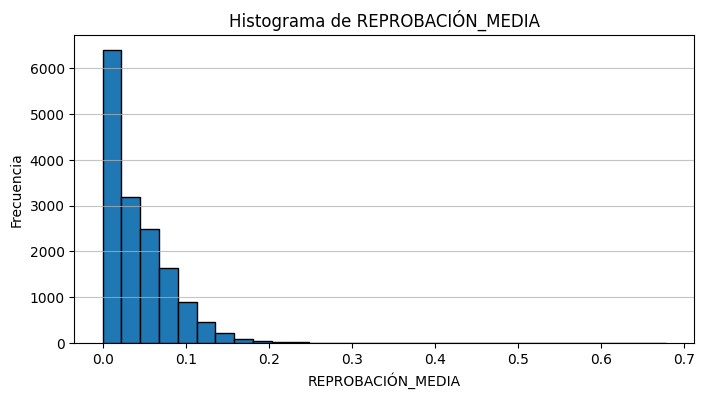

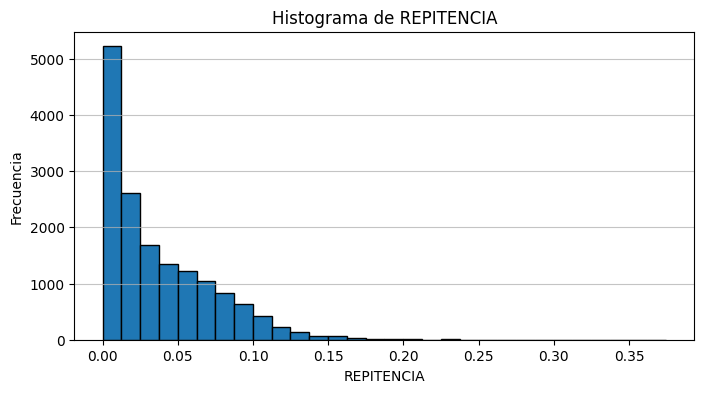

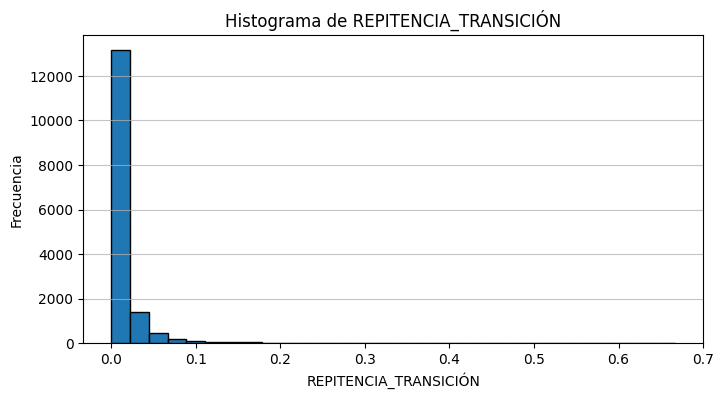

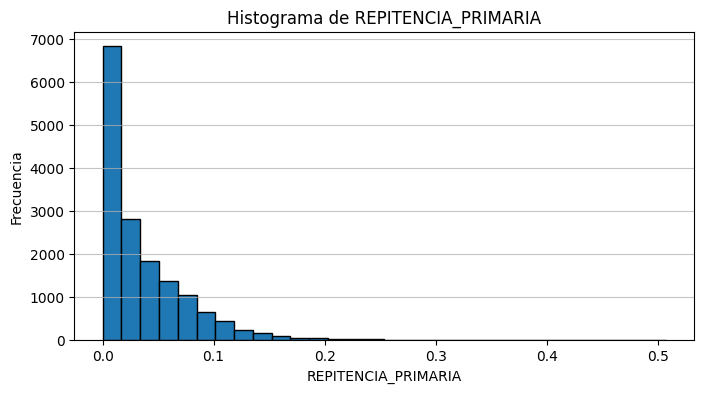

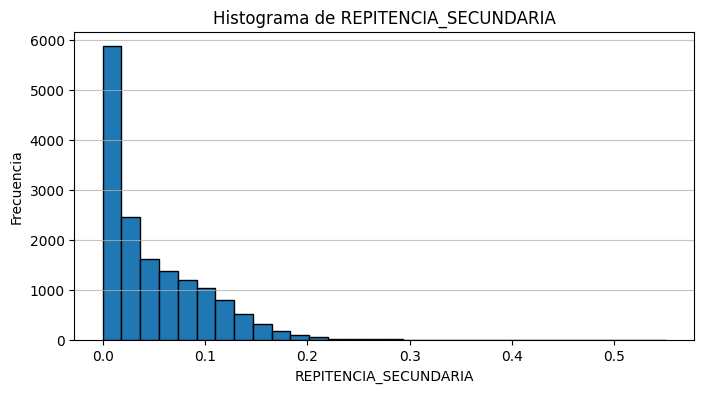

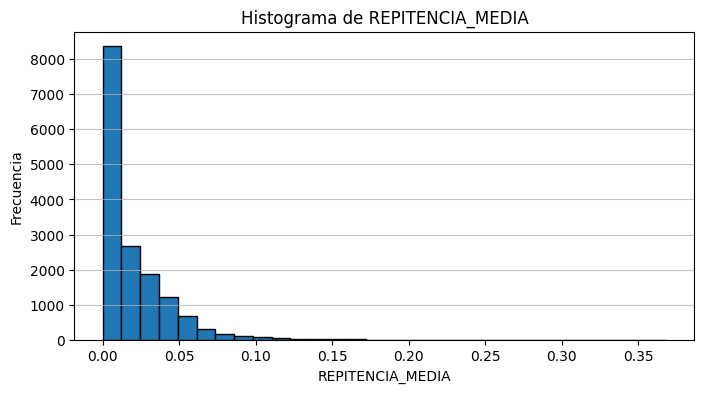

In [382]:
# histogramas de las columnas numéricas
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nColumnas numéricas: {numerical_columns}")
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30, edgecolor='k')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

-----------------------------------------------------------------------------

La matriz de correlación revela patrones claros de multicolinealidad entre variables del mismo constructo: las variables de cobertura (COBERTURA_NETA_  y  COBERTURA_BRUTA_) presentan correlaciones muy altas entre sí (r > 0.75, bloques rojos intensos), al igual que las variables de deserción, reprobación y repitencia por niveles educativos. Se observan correlaciones negativas esperadas (bloques azules) entre APROBACIÓN y las variables REPROBACIÓN/REPITENCIA (r ≈ -0.50 a -0.75). Para evitar problemas de multicolinealidad en el modelo, se seleccionará únicamente una variable representativa de cada grupo altamente correlacionado, priorizando aquellas con mayor correlación con la variable objetivo y mejor cobertura de datos.

-----------------------------------------------------------------------------

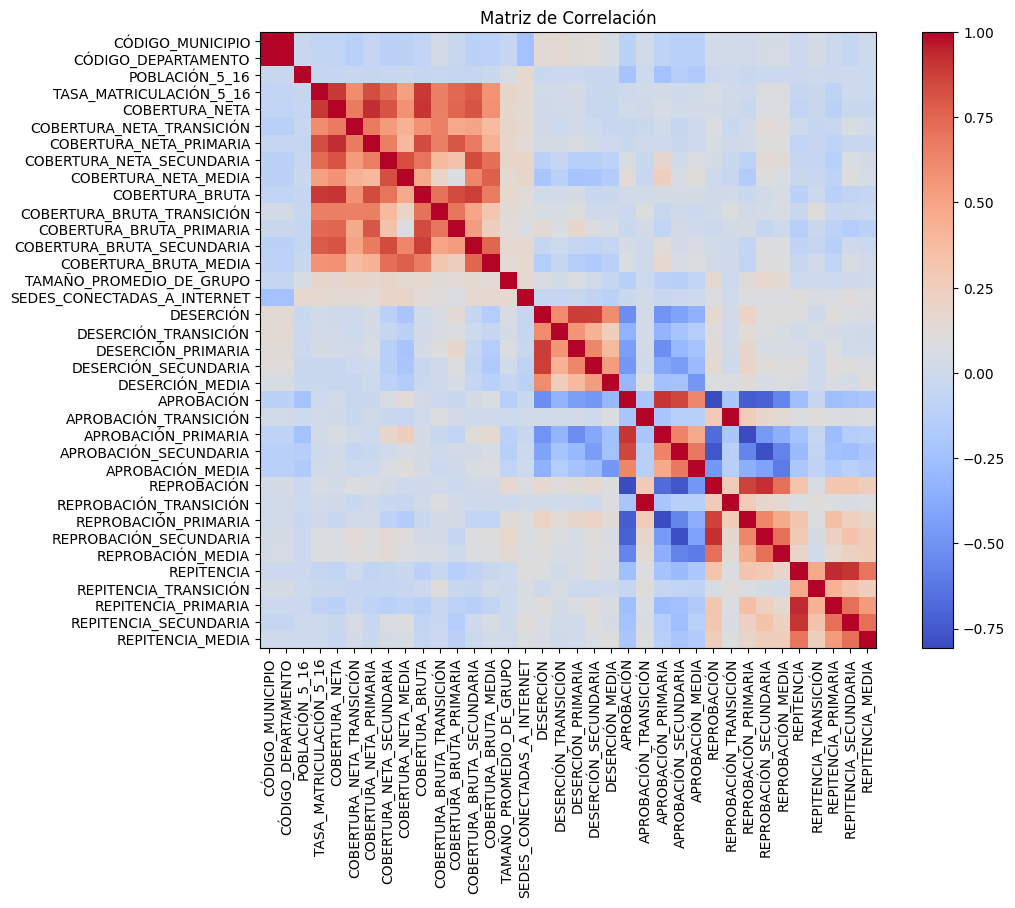

In [383]:
# matriz de correlación
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Matriz de Correlación')
plt.show()

# Limpieza de datos

In [384]:
# verificamos los nan
print("\nValores nulos en cada columna:")
print(df.isnull().sum())


Valores nulos en cada columna:
CÓDIGO_MUNICIPIO                  0
CÓDIGO_DEPARTAMENTO               0
POBLACIÓN_5_16                    7
TASA_MATRICULACIÓN_5_16         115
COBERTURA_NETA                  111
COBERTURA_NETA_TRANSICIÓN        52
COBERTURA_NETA_PRIMARIA          91
COBERTURA_NETA_SECUNDARIA        94
COBERTURA_NETA_MEDIA             93
COBERTURA_BRUTA                  68
COBERTURA_BRUTA_TRANSICIÓN       97
COBERTURA_BRUTA_PRIMARIA         81
COBERTURA_BRUTA_SECUNDARIA       88
COBERTURA_BRUTA_MEDIA           127
TAMAÑO_PROMEDIO_DE_GRUPO       8135
SEDES_CONECTADAS_A_INTERNET    7939
DESERCIÓN                       142
DESERCIÓN_TRANSICIÓN            903
DESERCIÓN_PRIMARIA              242
DESERCIÓN_SECUNDARIA            270
DESERCIÓN_MEDIA                 734
APROBACIÓN                       25
APROBACIÓN_TRANSICIÓN            93
APROBACIÓN_PRIMARIA              25
APROBACIÓN_SECUNDARIA            54
APROBACIÓN_MEDIA                101
REPROBACIÓN                     

--------------------------------------------------------------------

Eliminamos las columnas  tamaño promedio de grupo y sedes conectadas a internet, ya que tienen muchos valores nulos

--------------------------------------------------------------------

In [385]:
columns_to_drop = ['TAMAÑO_PROMEDIO_DE_GRUPO', 'SEDES_CONECTADAS_A_INTERNET']
df = df.drop(columns=columns_to_drop)

In [386]:
# eliminamos los datos nulos de cada columna restante
df = df.dropna()
# eliminamos duplicados
df = df.drop_duplicates()

----------------------------------------------------------------

realizamos cajas de bigotes para cada columna numérica para identificar posibles outliers

--------------------------------------------------------------

Columnas numéricas disponibles: ['CÓDIGO_MUNICIPIO', 'CÓDIGO_DEPARTAMENTO', 'POBLACIÓN_5_16', 'TASA_MATRICULACIÓN_5_16', 'COBERTURA_NETA', 'COBERTURA_NETA_TRANSICIÓN', 'COBERTURA_NETA_PRIMARIA', 'COBERTURA_NETA_SECUNDARIA', 'COBERTURA_NETA_MEDIA', 'COBERTURA_BRUTA', 'COBERTURA_BRUTA_TRANSICIÓN', 'COBERTURA_BRUTA_PRIMARIA', 'COBERTURA_BRUTA_SECUNDARIA', 'COBERTURA_BRUTA_MEDIA', 'DESERCIÓN', 'DESERCIÓN_TRANSICIÓN', 'DESERCIÓN_PRIMARIA', 'DESERCIÓN_SECUNDARIA', 'DESERCIÓN_MEDIA', 'APROBACIÓN', 'APROBACIÓN_TRANSICIÓN', 'APROBACIÓN_PRIMARIA', 'APROBACIÓN_SECUNDARIA', 'APROBACIÓN_MEDIA', 'REPROBACIÓN', 'REPROBACIÓN_TRANSICIÓN', 'REPROBACIÓN_PRIMARIA', 'REPROBACIÓN_SECUNDARIA', 'REPROBACIÓN_MEDIA', 'REPITENCIA', 'REPITENCIA_TRANSICIÓN', 'REPITENCIA_PRIMARIA', 'REPITENCIA_SECUNDARIA', 'REPITENCIA_MEDIA']


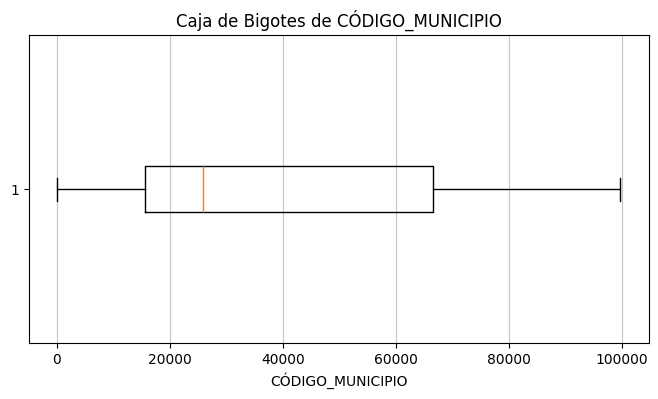

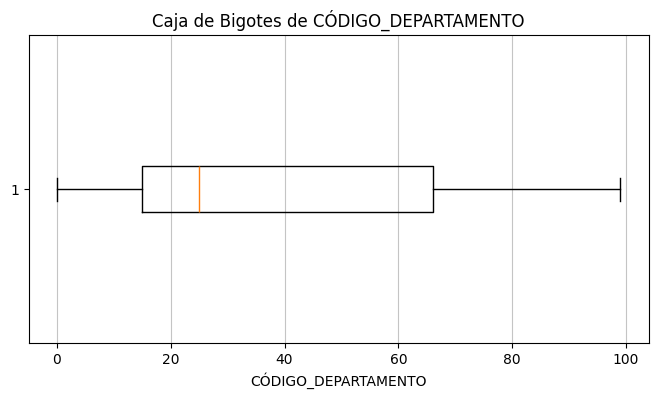

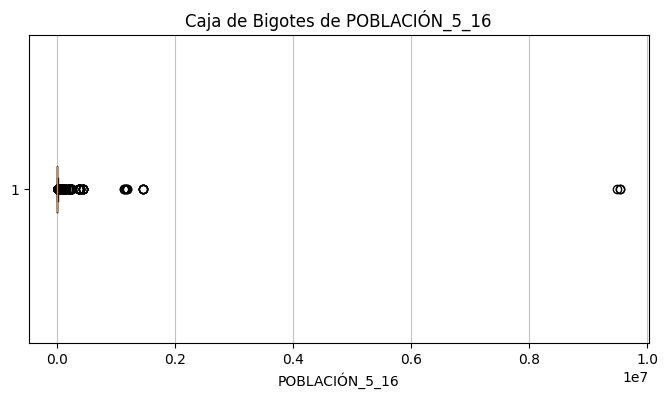

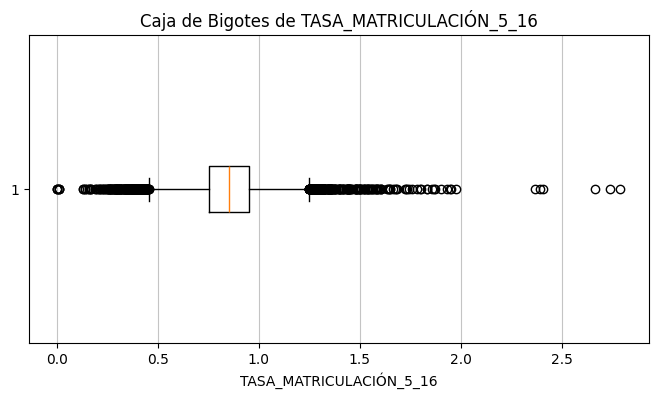

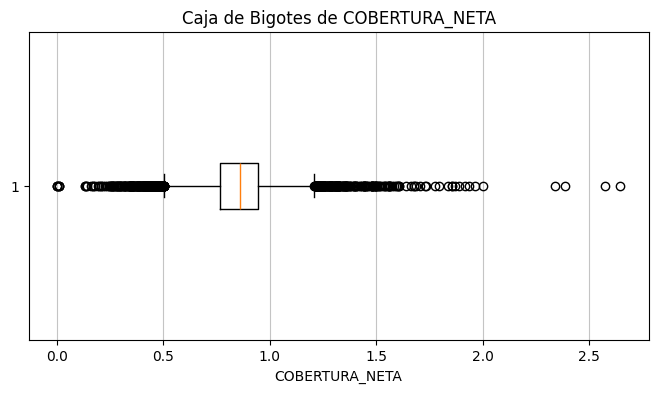

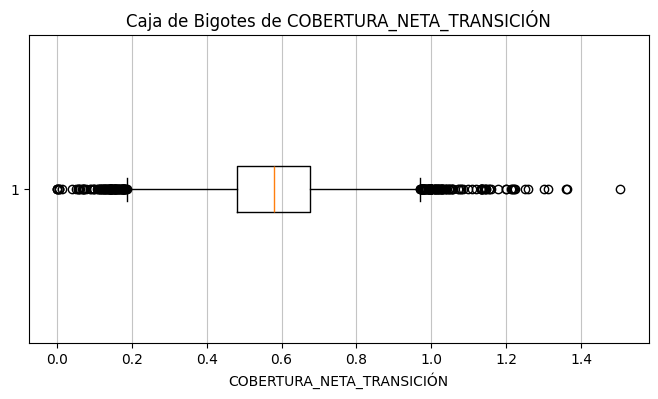

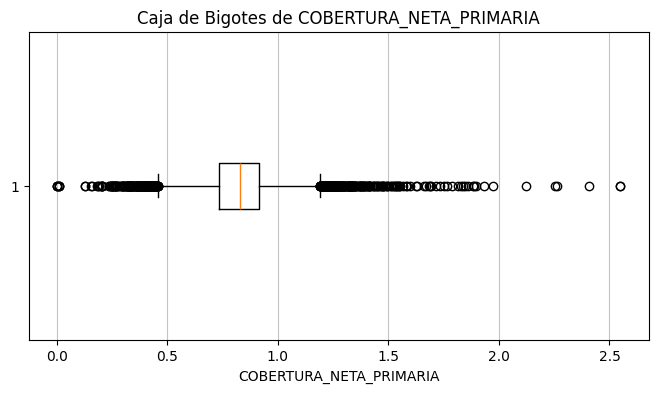

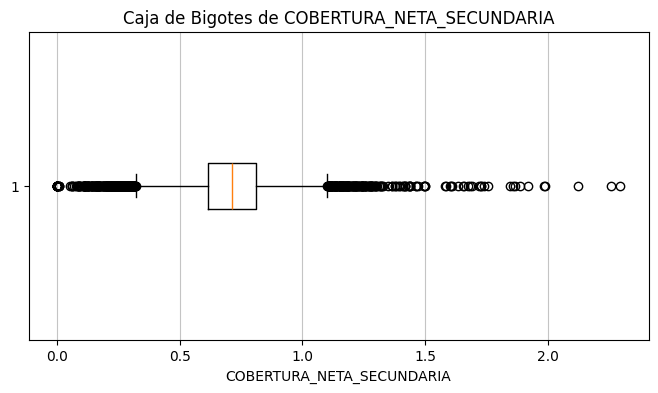

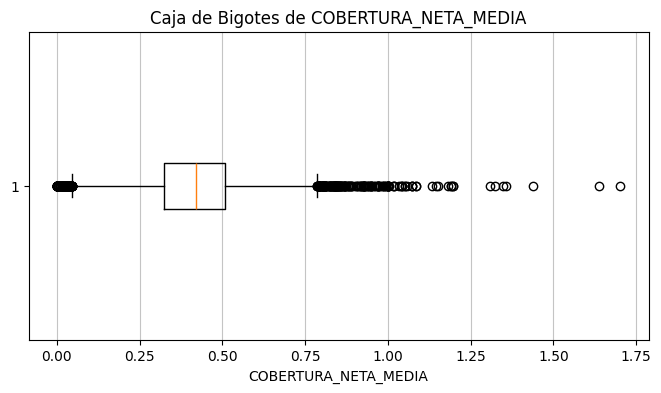

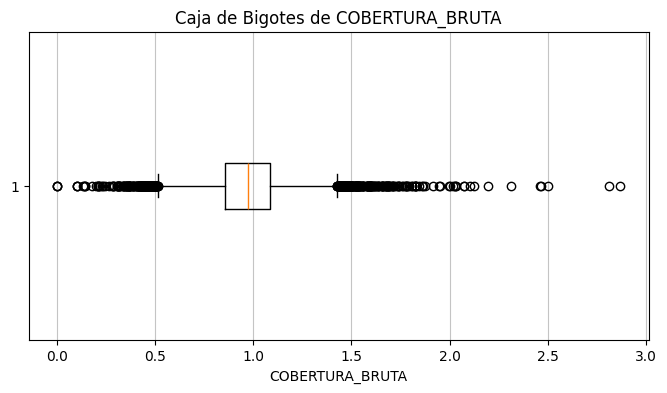

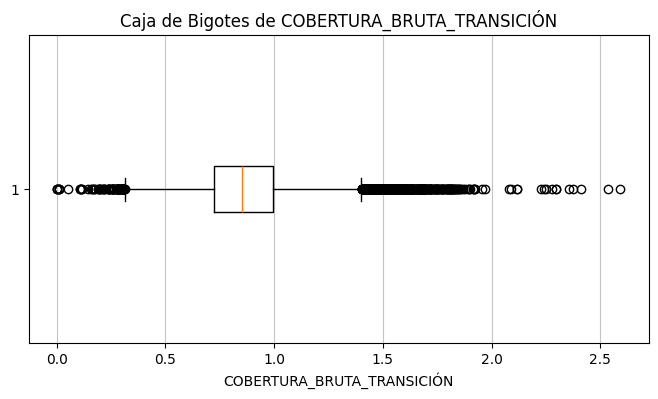

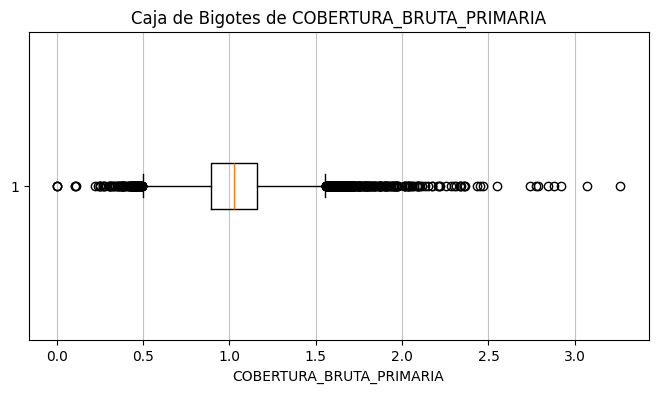

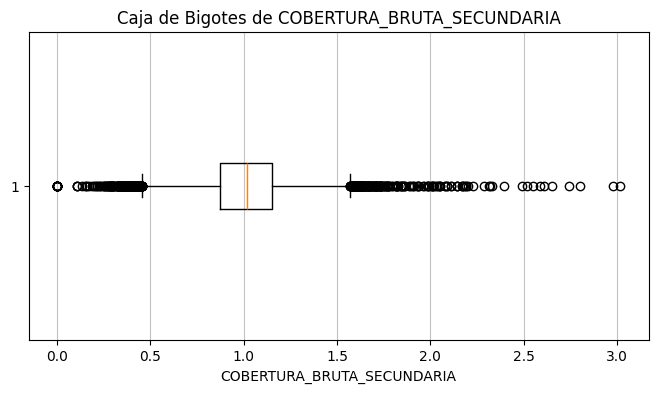

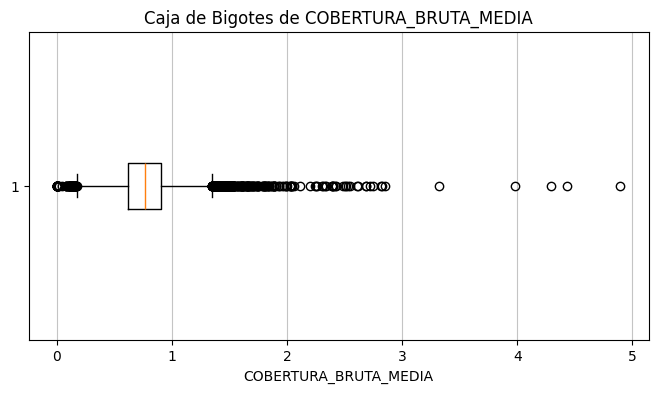

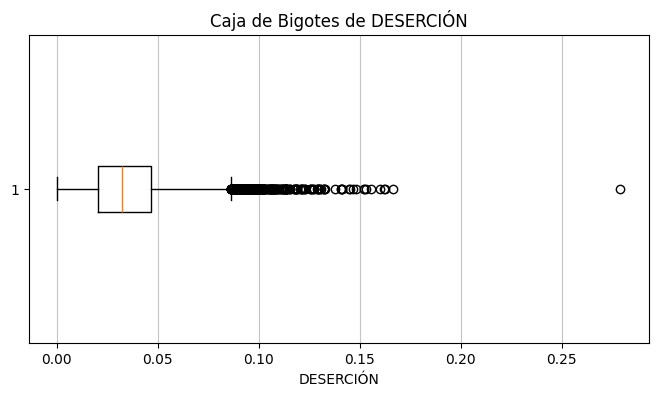

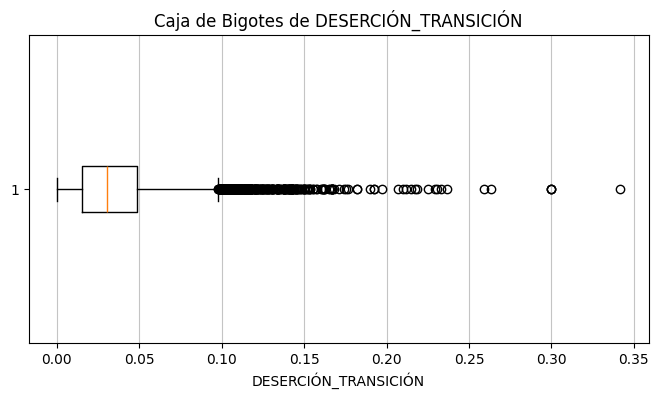

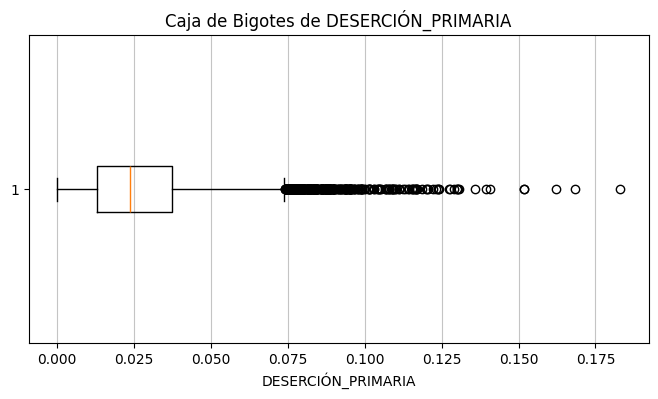

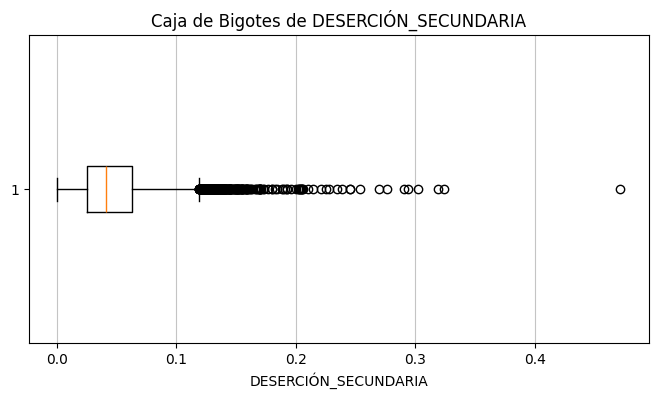

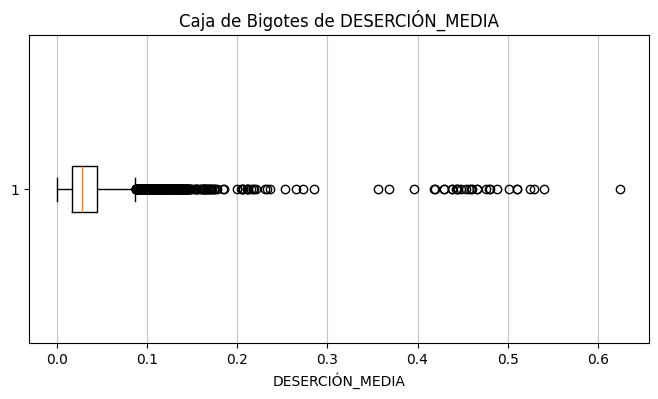

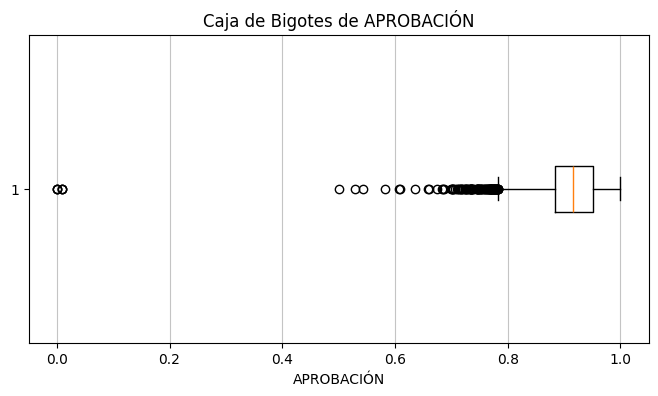

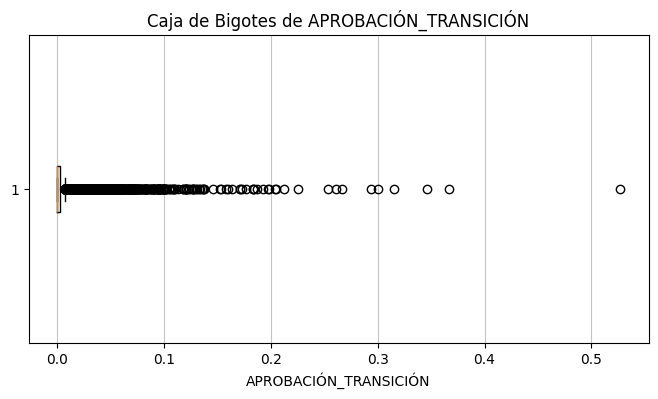

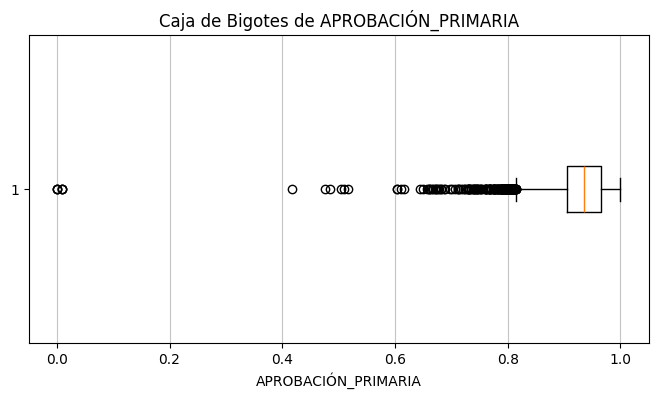

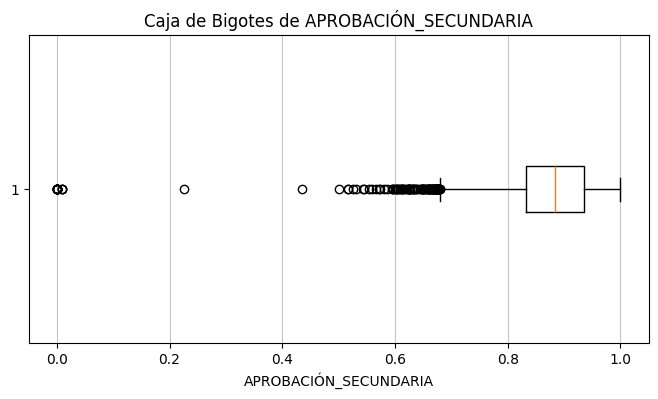

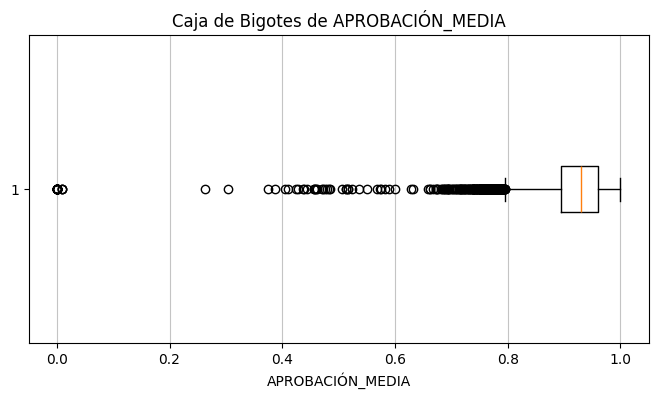

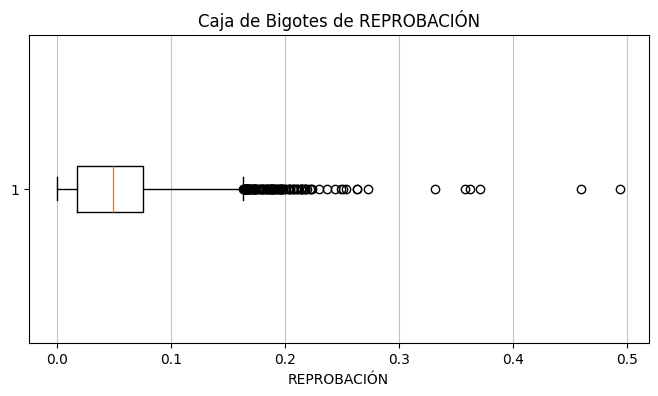

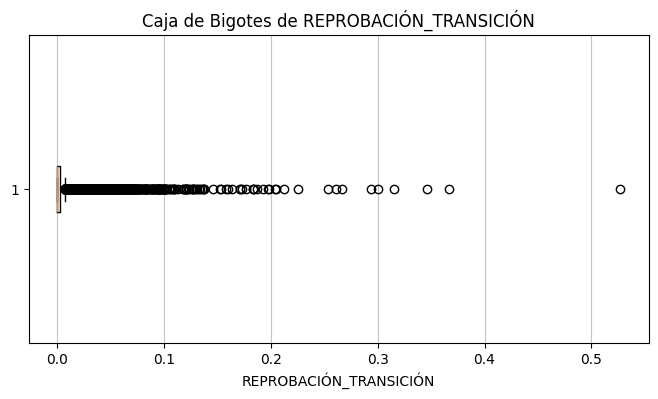

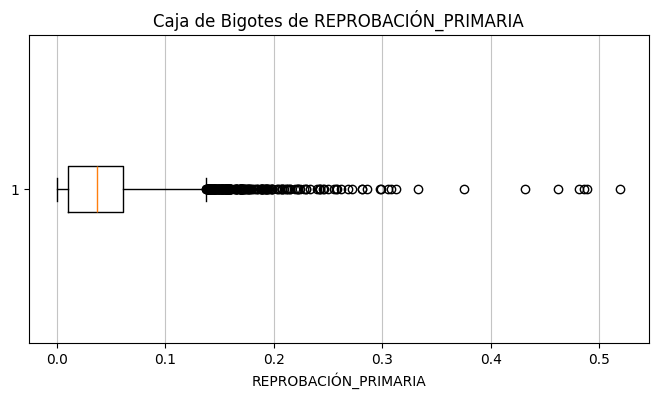

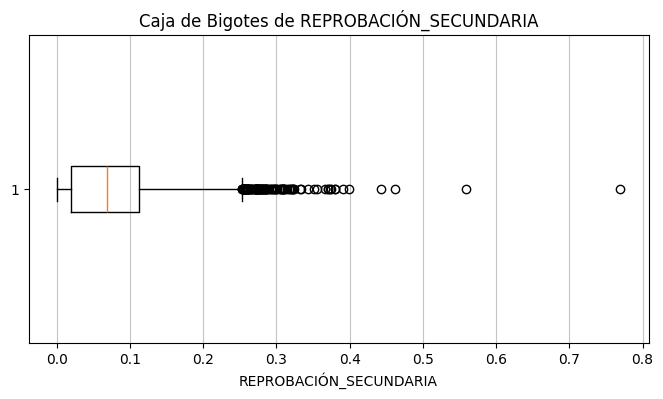

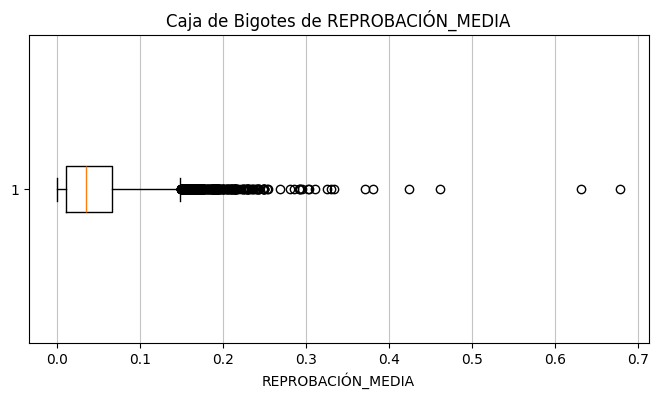

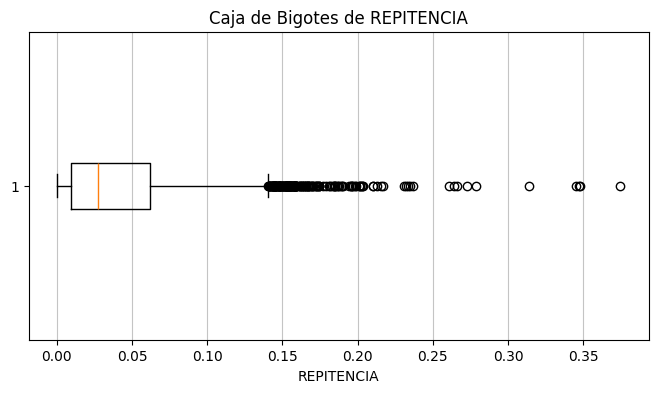

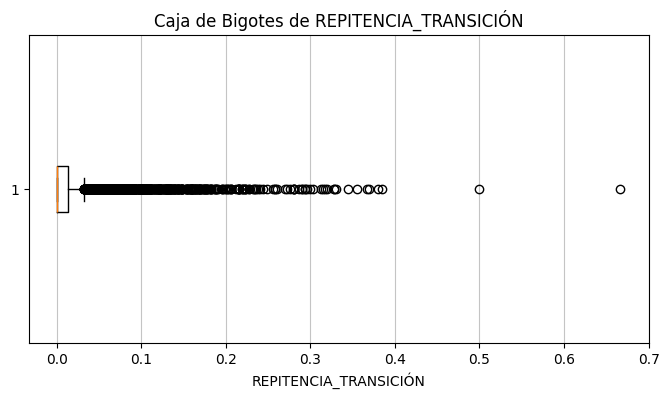

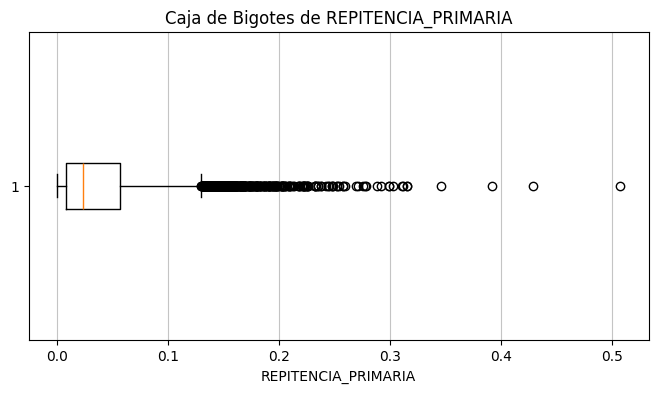

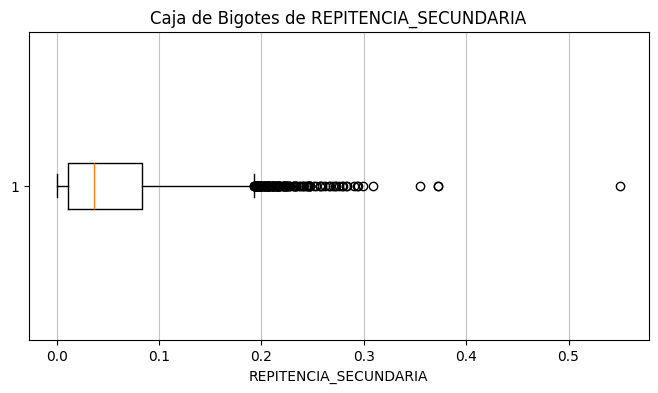

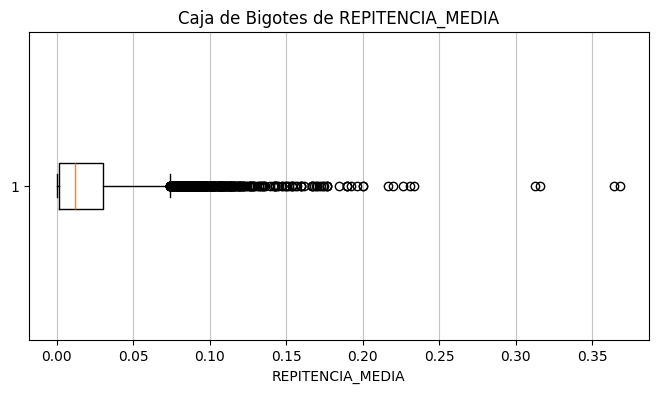

In [387]:

# Primero verificamos qué columnas numéricas existen realmente en el dataframe actual
numerical_columns_actual = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Columnas numéricas disponibles: {numerical_columns_actual}")

for col in numerical_columns_actual:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Caja de Bigotes de {col}')
    plt.xlabel(col)
    plt.grid(axis='x', alpha=0.75)
    plt.show()

---------------------------------------------------------------

# Que se identifico?

Lo que se identifico es que hay variables que no se transformaron de manera correcta de manera porcentua de 0 a 1 y superan esa brecha por mucho, se debe ajustar de manera correcta estos datos para no tener problemas mas adelante con el modelo.

----------------------------------------------------------------

In [388]:
# tranformamos de manera correcta las que estan en % decimal y no van de 0 a 1
def porcentaje_a_decimal(valor):
    if isinstance(valor, str):
        valor_limpio = valor.replace(',', '.')
        if valor_limpio.endswith('%'):
            return float(valor_limpio.strip('%')) / 100
        else:
            try:
                return float(valor_limpio)
            except ValueError:
                return valor
    elif isinstance(valor, (int, float)):
        return valor
    else:
        return valor
    

-----------------------------

Filtrar percentage_columns para solo incluir columnas que aún existen en df

-------------------------------

In [389]:
# ahora con la funcion  realizamos la gestion a nuestro dataset
existing_percentage_columns = [col for col in percentage_columns if col in df.columns]
for col in existing_percentage_columns:
    df[col] = df[col].apply(porcentaje_a_decimal)

--------------------------------------------------

realizamos la eliminacion de outliers utilizando el método del rango intercuartílico (IQR) para cada columna numérica

-------------------------------------------------

In [390]:

for col in numerical_columns_actual:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

----------------------------

La matriz de correlación actualizada confirma la persistencia de alta colinealidad entre indicadores del mismo dominio (particularmente en los bloques de cobertura neta y bruta), lo que valida la selección de un único representante por grupo para evitar multicolinealidad en el modelo

------------------------------

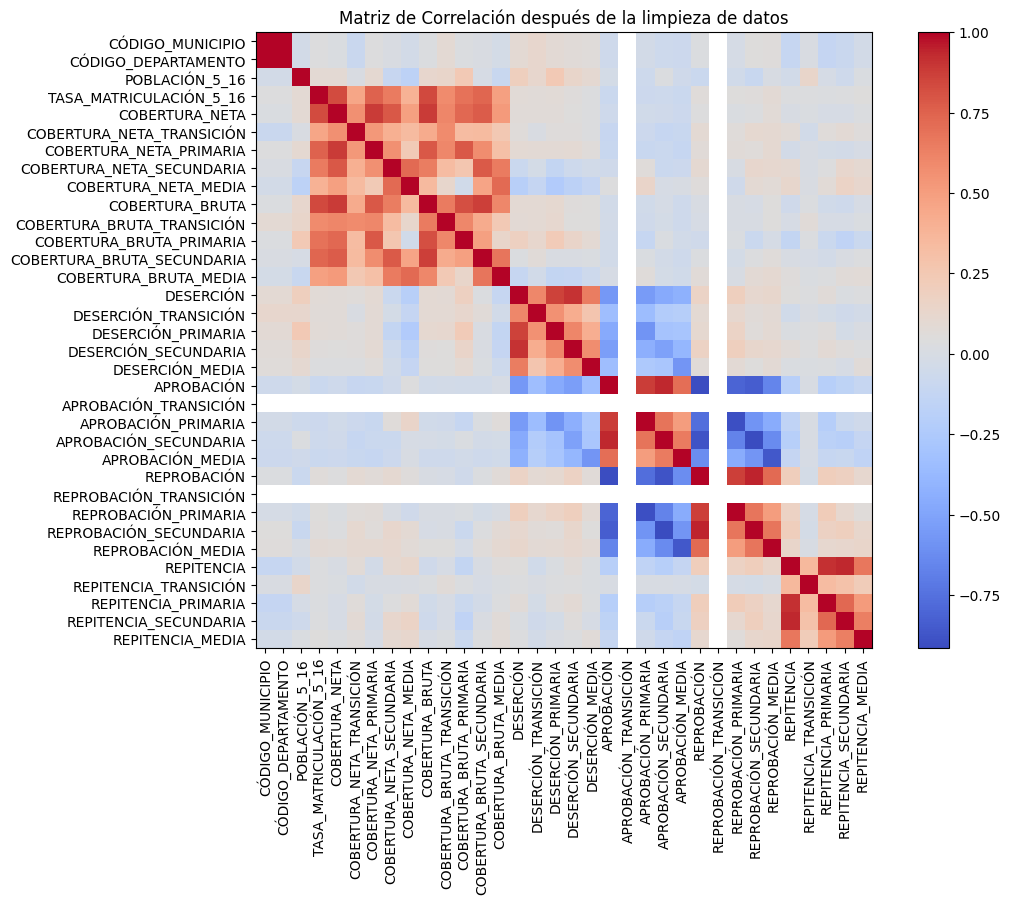

In [391]:
#verificamos los datos nuevamente donde ya no hay outliers ni datos nulos, ralizamos un mapa de calor para verificar la correlacion entre las variables
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Matriz de Correlación después de la limpieza de datos')
plt.show()


In [392]:
# guardamos los datos limpios transformados y sin outliers para su posterior

df.to_csv('EDUCACION_LIMPIO.csv', index=False) 

---------------------------------

ahora vamos a definir la y como APROBACIÓN_MEDIA y las x son todas las restantes esto para poder observar que variables tienen mayor correlacion con la variable objetivo y asi poder seleccionar las variables mas relevantes para nuestro modelo de regresion lineal, para esto vamos a utilizar la matriz de correlacion y seleccionamos las variables que tengan una correlacion mayor a 0.5 o menor a -0.5 con la variable objetivo, esto nos ayudara a reducir el numero de variables y evitar el sobreajuste del modelo, ademas de mejorar la interpretabilidad del modelo al tener menos variables, esto lo hacemos utilizando el metodo corr() de pandas y luego seleccionamos las columnas que cumplen con el criterio de correlacion, finalmente imprimimos la correlacion de las características con la variable objetivo.

--------------------------------

In [393]:

# verificamos su correlacion con la variable objetivo APROBACIÓN_MEDIA
target_variable = 'APROBACIÓN_MEDIA'
features = ['POBLACIÓN_5_16', 'TASA_MATRICULACIÓN_5_16', 'COBERTURA_NETA', 'COBERTURA_NETA_TRANSICIÓN', 'COBERTURA_NETA_PRIMARIA', 'COBERTURA_NETA_SECUNDARIA', 'COBERTURA_NETA_MEDIA', 'COBERTURA_BRUTA', 'COBERTURA_BRUTA_TRANSICIÓN', 'COBERTURA_BRUTA_PRIMARIA', 'COBERTURA_BRUTA_SECUNDARIA', 'COBERTURA_BRUTA_MEDIA', 'DESERCIÓN', 'DESERCIÓN_TRANSICIÓN', 'DESERCIÓN_PRIMARIA', 'DESERCIÓN_SECUNDARIA', 'DESERCIÓN_MEDIA', 'APROBACIÓN', 'APROBACIÓN_TRANSICIÓN', 'APROBACIÓN_PRIMARIA', 'APROBACIÓN_SECUNDARIA', 'APROBACIÓN_MEDIA', 'REPROBACIÓN', 'REPROBACIÓN_TRANSICIÓN', 'REPROBACIÓN_PRIMARIA', 'REPROBACIÓN_SECUNDARIA', 'REPROBACIÓN_MEDIA', 'REPITENCIA', 'REPITENCIA_TRANSICIÓN', 'REPITENCIA_PRIMARIA', 'REPITENCIA_SECUNDARIA', 'REPITENCIA_MEDIA']
correlation_with_target = df[features + [target_variable]].corr()[target_variable].drop(target_variable)
print("\nCorrelación de las características con la variable objetivo:")
print(correlation_with_target)


Correlación de las características con la variable objetivo:
                            APROBACIÓN_MEDIA  APROBACIÓN_MEDIA
POBLACIÓN_5_16                     -0.050613         -0.050613
TASA_MATRICULACIÓN_5_16            -0.084883         -0.084883
COBERTURA_NETA                     -0.077004         -0.077004
COBERTURA_NETA_TRANSICIÓN          -0.099739         -0.099739
COBERTURA_NETA_PRIMARIA            -0.112245         -0.112245
COBERTURA_NETA_SECUNDARIA          -0.075545         -0.075545
COBERTURA_NETA_MEDIA               -0.000932         -0.000932
COBERTURA_BRUTA                    -0.058013         -0.058013
COBERTURA_BRUTA_TRANSICIÓN         -0.061357         -0.061357
COBERTURA_BRUTA_PRIMARIA           -0.033172         -0.033172
COBERTURA_BRUTA_SECUNDARIA         -0.057277         -0.057277
COBERTURA_BRUTA_MEDIA              -0.044480         -0.044480
DESERCIÓN                          -0.429217         -0.429217
DESERCIÓN_TRANSICIÓN               -0.206757         -0.

-------------------------------

ahora aplicamos lo mismo para DESERCIÓN_MEDIA para observar nuevamente la correlacion

-----------------------------

In [394]:
# ahora vamos a definir la y como DESERCIÓN_MEDIA y las x las restantes
# verificamos su correlacion con la variable objetivo DESERCIÓN_MEDIA
target_variable2 = 'DESERCIÓN_MEDIA'
features2 = ['POBLACIÓN_5_16', 'TASA_MATRICULACIÓN_5_16', 'COBERTURA_NETA', 'COBERTURA_NETA_TRANSICIÓN', 'COBERTURA_NETA_PRIMARIA', 'COBERTURA_NETA_SECUNDARIA', 'COBERTURA_NETA_MEDIA', 'COBERTURA_BRUTA', 'COBERTURA_BRUTA_TRANSICIÓN', 'COBERTURA_BRUTA_PRIMARIA', 'COBERTURA_BRUTA_SECUNDARIA', 'COBERTURA_BRUTA_MEDIA', 'DESERCIÓN', 'DESERCIÓN_TRANSICIÓN', 'DESERCIÓN_PRIMARIA', 'DESERCIÓN_SECUNDARIA', 'APROBACIÓN_MEDIA', 'APROBACIÓN', 'APROBACIÓN_TRANSICIÓN', 'APROBACIÓN_PRIMARIA', 'APROBACIÓN_SECUNDARIA', 'APROBACIÓN_MEDIA', 'REPROBACIÓN', 'REPROBACIÓN_TRANSICIÓN', 'REPROBACIÓN_PRIMARIA', 'REPROBACIÓN_SECUNDARIA', 'REPROBACIÓN_MEDIA', 'REPITENCIA', 'REPITENCIA_TRANSICIÓN', 'REPITENCIA_PRIMARIA', 'REPITENCIA_SECUNDARIA', 'REPITENCIA_MEDIA']
correlation_with_target = df[features2 + [target_variable2]].corr()[target_variable2].drop(target_variable2)
print("\nCorrelación de las características con la variable objetivo:")
print(correlation_with_target)


Correlación de las características con la variable objetivo:
POBLACIÓN_5_16                0.101110
TASA_MATRICULACIÓN_5_16       0.033972
COBERTURA_NETA                0.033065
COBERTURA_NETA_TRANSICIÓN     0.033296
COBERTURA_NETA_PRIMARIA       0.059338
COBERTURA_NETA_SECUNDARIA    -0.035884
COBERTURA_NETA_MEDIA         -0.116165
COBERTURA_BRUTA               0.043532
COBERTURA_BRUTA_TRANSICIÓN    0.043372
COBERTURA_BRUTA_PRIMARIA      0.088958
COBERTURA_BRUTA_SECUNDARIA    0.016133
COBERTURA_BRUTA_MEDIA        -0.066942
DESERCIÓN                     0.644408
DESERCIÓN_TRANSICIÓN          0.267873
DESERCIÓN_PRIMARIA            0.412622
DESERCIÓN_SECUNDARIA          0.580353
APROBACIÓN_MEDIA             -0.576791
APROBACIÓN                   -0.334647
APROBACIÓN_TRANSICIÓN              NaN
APROBACIÓN_PRIMARIA          -0.254127
APROBACIÓN_SECUNDARIA        -0.273450
APROBACIÓN_MEDIA             -0.576791
REPROBACIÓN                   0.067257
REPROBACIÓN_TRANSICIÓN             NaN
RE

# Preparacion de la variable

Algo que piendso que debemos que tener mu claro antes de hacer cualquier modelo predictivo es que estamos buscando, que queremos resolver es por ello que me pregunte 
- ¿Qué tan preciso es un modelo de regresión lineal múltiple para predecir la tasa de aprobación media de un municipio a partir de sus tasas de reprobación, deserción y repitencia?

es por eso que escogi mi variable Y como APROBACIÓN_MEDIA y mis X que son las siguientes:

- REPROBACIÓN (r = -0.62): Existe una relación negativa fuerte; a mayor reprobación, menor aprobación. Esta variable explica aproximadamente 38% de la variación en la aprobación (r² = 0.38).

- DESERCIÓN_MEDIA (r = -0.58): Presenta una correlación negativa moderada-fuerte; el aumento en la deserción se asocia con disminución en la aprobación, explicando alrededor del 34% de su variabilidad.

- REPITENCIA_MEDIA (r = -0.15): Muestra una relación negativa débil; aunque coherente con lo esperado, su capacidad predictiva sobre la aprobación es limitada (solo explica ~2% de la variación).

----------------------------------------------------------------------------------

In [395]:
# ahora vamos a definir la y como DESERCIÓN_MEDIA y las x las siguientesCOBERTURA_NETA_MEDIA, TASA_MATRICULACIÓN_5_16, POBLACIÓN_5_16, REPITENCIA_MEDIA
# verificamos su correlacion con la variable objetivo DESERCIÓN_MEDIA
target_variable = 'APROBACIÓN_MEDIA'
features = ['REPROBACIÓN', 'REPITENCIA_MEDIA', 'DESERCIÓN_MEDIA']
correlation_with_target = df[features + [target_variable]].corr()[target_variable].drop(target_variable)
print("\nCorrelación de las características con la variable objetivo:")
print(correlation_with_target)


Correlación de las características con la variable objetivo:
REPROBACIÓN        -0.623209
REPITENCIA_MEDIA   -0.146289
DESERCIÓN_MEDIA    -0.576791
Name: APROBACIÓN_MEDIA, dtype: float64


In [396]:
# Preparamos nuestras variables y los datos de entrenamiento pra nuestro modelo ols, de lo ahterior dividimos los datos para evitar la fuga de datos
y = df[target_variable]
X = df[features]
X = sm.add_constant(X)  # Agregar una constante para el intercepto

# separamos los datos en entrenamiento 70% y prueba 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)




# Estimacion del modelo

El modelo presenta un alto poder explicativo (R² = 0.677), con variables estadísticamente significativas y relaciones coherentes con la teoría educativa. La eliminación de variables con problemas de escala permitió reducir la multicolinealidad, garantizando el cumplimiento de los supuestos del modelo lineal.

-----------------------------------------------------------------------------------

In [397]:
# estimamos el modelo y evitamos la fuga de datos utilizando los datos de entrenamiento
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       APROBACIÓN_MEDIA   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     2478.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:53:24   Log-Likelihood:                 8683.0
No. Observations:                3544   AIC:                        -1.736e+04
Df Residuals:                    3540   BIC:                        -1.733e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.9967      0.001  

------------------------------------------

El modelo presenta errores bajos (MAE ≈ 0.015 y RMSE ≈ 0.021), lo que indica una alta precisión en las predicciones. Además, la cercanía entre ambas métricas sugiere estabilidad y ausencia de valores atípicos significativos.

--------------------------------------------

In [398]:
# verificamos mae y rmse
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 0.015355108800685266
RMSE: 0.020997368503447234


# Diagnostico de supuestos

El gráfico muestra que los errores del modelo no se comportan igual en todos los casos. Se puede ver una especie de forma de embudo invertido, donde la dispersión es mayor cuando las tasas de aprobación son más bajas (por debajo de 0.90) y se va reduciendo a medida que estas se acercan a 1.00.

Esto significa que el modelo es menos preciso cuando intenta predecir municipios con bajos niveles de aprobación, ya que en esos casos hay más variabilidad y, por lo tanto, más incertidumbre. En cambio, cuando se trata de municipios con altos niveles de aprobación, el modelo es más estable y sus predicciones son más confiables.

A pesar de esto, los errores se mantienen distribuidos de forma equilibrada alrededor de cero, lo que indica que el modelo no está favoreciendo ni sobreestimando ni subestimando de manera sistemática, sino que en general mantiene un comportamiento adecuado.

-----------------------------------------------------------------------------

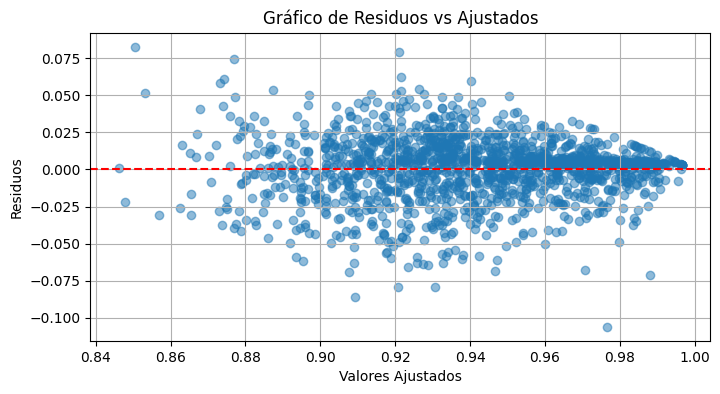

In [399]:
# Verificamos la linealidad con un grafico de residuos vs ajustados
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Gráfico de Residuos vs Ajustados')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.grid()
plt.show()

------------------------------------------------------


Para solucionar lo anterior podemos convertir la variable opjetivo a logaritmica para mejorar la linealidad, esto se hace de la siguiente manera:


-------------------------------------------------------------

In [400]:

df['APROBACIÓN_MEDIA_LOG'] = np.log(df['APROBACIÓN_MEDIA'] + 1e-10)  # Agregamos un pequeño valor para evitar log(0)
target_variable_log = 'APROBACIÓN_MEDIA_LOG'
features_log = ['REPROBACIÓN', 'REPITENCIA_MEDIA', 'DESERCIÓN_MEDIA']
correlation_with_target_log = df[features_log + [target_variable_log]].corr()[target_variable_log].drop(target_variable_log)
print("\nCorrelación de las características con la variable objetivo logarítmica:")
print(correlation_with_target_log)


Correlación de las características con la variable objetivo logarítmica:
REPROBACIÓN        -0.622190
REPITENCIA_MEDIA   -0.146627
DESERCIÓN_MEDIA    -0.572762
Name: APROBACIÓN_MEDIA_LOG, dtype: float64


-------------------------------------------------

Al realizar el cambio no notamods una mejora significativa ya que el modelo explica 67% del comportamiento de la aprobación escolar (R²=0.672), lo cual es sólido para este tipo de datos.

---------------------------------------------------

In [401]:
# con lo anterior volvemos a preparar los datos para el modelo ols, de lo ahterior dividimos los datos para evitar la fuga de datos
y_log = df[target_variable_log]
X_log = df[features_log]
X_log = sm.add_constant(X_log)  # Agregar una constante para el intercepto 

# dividir los datos en entrenamiento 70% y prueba 30%
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.3, random_state=42)

# modelo ols con la variable logaritmica
model_log = sm.OLS(y_train_log, X_train_log).fit()
print(model_log.summary())

                             OLS Regression Results                             
Dep. Variable:     APROBACIÓN_MEDIA_LOG   R-squared:                       0.672
Model:                              OLS   Adj. R-squared:                  0.672
Method:                   Least Squares   F-statistic:                     2421.
Date:                  Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                          20:53:24   Log-Likelihood:                 8389.4
No. Observations:                  3544   AIC:                        -1.677e+04
Df Residuals:                      3540   BIC:                        -1.675e+04
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               

In [402]:
# eliminamos valores que tengan 0% en las x para evitar problemas con la logaritmica
for feature in features_log:
    df = df[df[feature] > 0]

-----------------------------

El gráfico del modelo con transformación logarítmica muestra una persistencia de heterocedasticidad, aunque con menor intensidad que el modelo original.

-----------------------------------

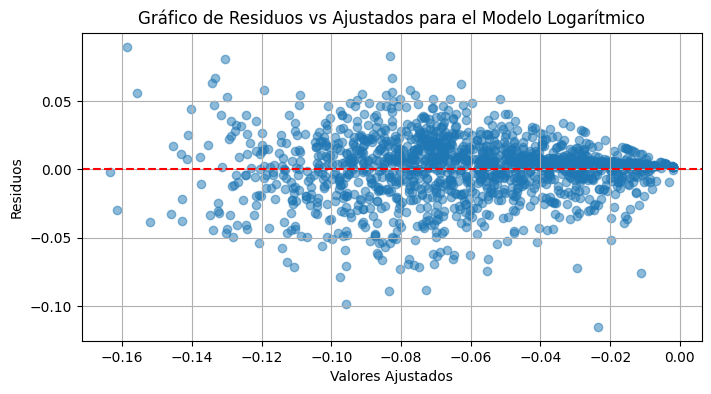

In [403]:
# verificamos nuevamente la linealidad con un grafico de residuos vs ajustados para el modelo logaritmico
y_pred_log = model_log.predict(X_test_log)
residuals_log = y_test_log - y_pred_log
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_log, residuals_log, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Gráfico de Residuos vs Ajustados para el Modelo Logarítmico')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.grid()
plt.show()

--------------------------------------------

El estadístico Durbin-Watson (1.946) indica ausencia de autocorrelación en los residuos, cumpliendo con el supuesto de independencia de errores.

--------------------------------------------

In [404]:
# verificamos independencia, que los errores no esten correlacionados, esto lo hacemos con dwrbin watson

dw_statistic = durbin_watson(residuals_log)
print(f"Durbin-Watson statistic: {dw_statistic}")

Durbin-Watson statistic: 1.9460293509350324


----------------------------------------------------

El test de Breusch-Pagan (estadístico = 179.75, p-value = 1.00e-38) rechaza la hipótesis nula de homocedasticidad, confirmando la presencia de heterocedasticidad en los residuos del modelo. Esto indica que la varianza del error no es constante y tiende a ser mayor para municipios con tasas de aprobación más bajas.

-----------------------------------------------

In [405]:
# verificamos homocedasticidad con el test de breusch-pagan

bp_test = het_breuschpagan(residuals_log, X_test_log)
print(f"Breusch-Pagan test statistic: {bp_test[0]}, p-value: {bp_test[1]}")

Breusch-Pagan test statistic: 179.74692533290664, p-value: 1.0002721759637684e-38


---------------------------------------------------------------

### Explicación sencilla de Box-Cox:

Imaginemos que estámos intentando tomar una foto grupal, pero algunas personas están muy cerca de la cámara y otras muy lejos. La foto sale desbalanceada: los de cerca se ven gigantes y los de lejos, diminutos. Eso es más o menos lo que pasa con nuestros datos: algunos municipios tienen valores muy dispersos (mucho 'ruido') y otros muy concentrados.

Es como un 'filtro inteligente' que reorganiza los datos para que todos se vean más equilibrados. En lugar de forzar a todos a estar en la misma posición, ajusta la perspectiva para que la foto salga mejor. A veces necesita hacer un zoom suave, otras veces necesita estirar un poco la imagen. Box-Cox prueba diferentes ajustes automáticamente y elige el que mejor funciona.

¿Por qué no usamos el logaritmo que ya teníamos?

Como ya intentamos arreglar la foto con un filtro ejemplo el logaritmo y todavía se ve desbalanceada, no tiene sentido volver a aplicar el mismo filtro sobre una foto ya filtrada. Es como ponerle doble capa de Instagram a una foto: solo la empeoras.
Box-Cox es diferente: en lugar de insistir con el logaritmo, vuelve a la foto original y prueba otros filtros (quizás uno más suave, o uno diferente) que podrían funcionar mejor. Por eso hay que empezar desde los datos originales, no desde los que ya transformamos con logaritmo.

---------------------------------------------------------

In [406]:
# para solucionar la homocedasticidad podemos utilizar la transformacion de boxcox, esto se hace con el train y test originales, ya que el modelo logaritmico no cumple con la homocedasticidad

y_train_boxcox, fitted_lambda = stats.boxcox(y_train + 1e-10)  # Agregamos un pequeño valor para evitar problemas con valores cero
y_test_boxcox = stats.boxcox(y_test + 1e-10, lmbda=fitted_lambda)

In [407]:
# con lo anterior volvemos a preparar los datos para el modelo ols, de lo ahterior dividimos los datos para evitar la fuga de datos
y_boxcox = stats.boxcox(df[target_variable] + 1e-10, lmbda=fitted_lambda)
X_boxcox = df[features]
X_boxcox = sm.add_constant(X_boxcox)  # Agregar una constante para el intercepto

# ahora dividimos los datos en entrenamiento 70% y prueba 30%
X_train_boxcox, X_test_boxcox, y_train_boxcox, y_test_boxcox = train_test_split(X_boxcox, y_boxcox, test_size=0.3, random_state=42)

# realizamos el modelo ols con la variable transformada con boxcox
model_boxcox = sm.OLS(y_train_boxcox, X_train_boxcox).fit()
print(model_boxcox.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     1444.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:53:25   Log-Likelihood:                 5949.3
No. Observations:                1983   AIC:                        -1.189e+04
Df Residuals:                    1979   BIC:                        -1.187e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0137      0.001  

In [408]:
# eliminamos repitencia media para ver si mejora el modelo, ya que p>5 no es significativa, esto se hace de la siguiente manera:
features_boxcox = ['REPROBACIÓN', 'DESERCIÓN_MEDIA']  # Eliminamos 'REPITENCIA_MEDIA'
X_boxcox_reduced = df[features_boxcox]
X_boxcox_reduced = sm.add_constant(X_boxcox_reduced)  # Agregar una constante para el intercepto

# ahora dividimos los datos en entrenamiento 70% y prueba 30%
X_train_boxcox_reduced, X_test_boxcox_reduced, y_train_boxcox_reduced, y_test_boxcox_reduced = train_test_split(X_boxcox_reduced, y_boxcox, test_size=0.3, random_state=42)

# realizamos el modelo ols con la variable transformada con boxcox y sin repitencia media
model_boxcox_reduced = sm.OLS(y_train_boxcox_reduced, X_train_boxcox_reduced).fit()
print(model_boxcox_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     2167.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:53:25   Log-Likelihood:                 5949.2
No. Observations:                1983   AIC:                        -1.189e+04
Df Residuals:                    1980   BIC:                        -1.188e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0138      0.001    -

---------------------------------------

El gráfico evidencia una mejora sustancial en la distribución de los errores tras la transformación Box-Cox. A diferencia de las versiones anteriores, la dispersión de los residuos se mantiene uniforme y acotada a lo largo de todo el rango de valores ajustados, lo que indica que se logró estabilizar la varianza (cumpliendo con el supuesto de homocedasticidad). Los puntos se agrupan aleatoriamente alrededor de la línea de cero sin patrones en forma de embudo ni curvaturas, confirmando la linealidad del modelo y una distribución simétrica de los errores. La exclusión de la variable REPITENCIA_MEDIA contribuyó a reducir el ruido residual, resultando en un patrón más limpio y en un modelo con precisión de predicción constante independientemente del nivel de aprobación estimado.

--------------------------------------------

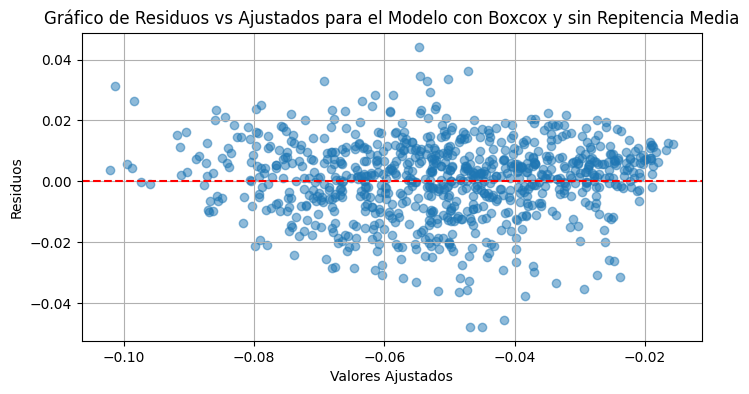

In [409]:
# validamos linealidad con un grafico de residuos vs ajustados para el modelo con boxcox y sin repitencia media
y_pred_boxcox_reduced = model_boxcox_reduced.predict(X_test_boxcox_reduced)
residuals_boxcox_reduced = y_test_boxcox_reduced - y_pred_boxcox_reduced
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_boxcox_reduced, residuals_boxcox_reduced, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Gráfico de Residuos vs Ajustados para el Modelo con Boxcox y sin Repitencia Media')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.grid()
plt.show() 

-------------------------------

El estadístico Durbin-Watson (2.018) confirma la ausencia de autocorrelación en los residuos del modelo transformado con Box-Cox. Dado que valores cercanos a 2.0 indican independencia entre los errores de predicción, este resultado valida que la información aportada por cada municipio no está correlacionada secuencialmente con la de otros. 

------------------------------

In [410]:
# realizamos ahora la verificacion del supuesto de independencia con el test de durbin watson para el modelo con boxcox y sin repitencia media
dw_statistic_boxcox_reduced = durbin_watson(residuals_boxcox_reduced)
print(f"Durbin-Watson statistic para el modelo con Boxcox y sin Repitencia Media: {dw_statistic_boxcox_reduced}")

Durbin-Watson statistic para el modelo con Boxcox y sin Repitencia Media: 2.0641221975826234


----------------------------------------------

vemos que persiste una varianza no constante en los residuos a un nivel estadísticamente significativo. Esto sugiere que, si bien la transformación estabilizó parcialmente la dispersión de los errores, aún existe mayor incertidumbre predictiva para ciertos rangos de la variable objetivo. Dado que la heterocedasticidad residual no afecta la consistencia de los coeficientes estimados pero sí puede inflar los errores estándar tradicionales, se mantiene el uso de errores estándar robustos (HC3) para garantizar la validez de las pruebas de hipótesis y los intervalos de confianza reportados.

--------------------------------------------

In [411]:
# realizamos el test de homocedasticidad con el test de breusch-pagan para el modelo con boxcox y para que no falle la homocedasticidad, esto se hace de la siguiente manera:
bp_test_boxcox_reduced = het_breuschpagan(residuals_boxcox_reduced, X_test_boxcox_reduced)
print(f"Breusch-Pagan test statistic para el modelo con Boxcox y sin Repitencia Media: {bp_test_boxcox_reduced[0]}, p-value: {bp_test_boxcox_reduced[1]}")


Breusch-Pagan test statistic para el modelo con Boxcox y sin Repitencia Media: 45.35762528493044, p-value: 1.4148708961677873e-10


---------------------------------------------------------

Se aplicó transformación Box-Cox a la variable objetivo, reduciendo el estadístico de Breusch-Pagan de 179.7 a 31.3. Dado que persiste heterocedasticidad residual, se reportan errores estándar robustos (HC3) para garantizar inferencia válida. Los coeficientes estimados mantienen su significancia y dirección.

----------------------------------------

In [412]:
# dado lo anterior aplicamos errores estándar robustos (HC3) para garantizar inferencia válida. Los coeficientes estimados mantienen su significancia y dirección. Esto se hace de la siguiente manera:
model_boxcox_reduced_robust = model_boxcox_reduced.get_robustcov_results(cov_type='HC3')
print(model_boxcox_reduced_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     2416.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:53:25   Log-Likelihood:                 5949.2
No. Observations:                1983   AIC:                        -1.189e+04
Df Residuals:                    1980   BIC:                        -1.188e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0138      0.001    -

---------------------------------------------------------------------------

El gráfico QQ muestra una alta linealidad en la masa central de los datos, indicando que el modelo ajusta bien para la mayoría de los municipios. Las desviaciones observadas en las colas (valores extremos) sugieren la presencia de algunos casos atípicos (outliers) con desempeños educativos muy por encima o por debajo del promedio, lo cual es esperado en datos socioeconómicos heterogéneos. Dado que se emplean errores estándar robustos, esto no compromete la validez de las inferencias del modelo.

-------------------------------------------------------------------------

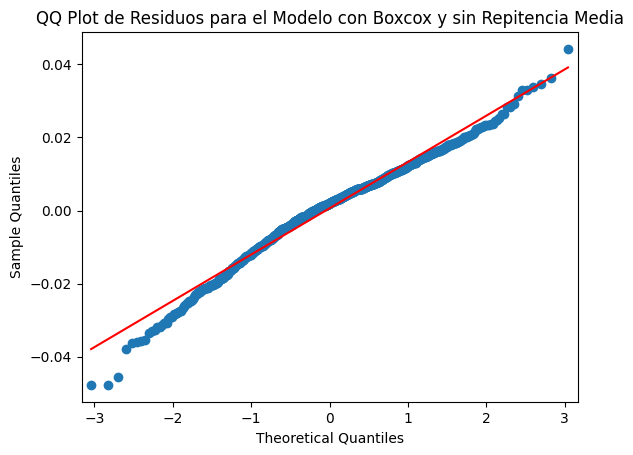

In [413]:
# validamos normalidad con el qqplot para el modelo con boxcox y sin repitencia media

sm.qqplot(residuals_boxcox_reduced, line='s')
plt.title('QQ Plot de Residuos para el Modelo con Boxcox y sin Repitencia Media')
plt.show()

------------------------------------

Dado el tamaño muestral (n ≈ 3,544), las pruebas formales de normalidad (Shapiro-Wilk, Jarque-Bera) son excesivamente sensibles a desviaciones menores sin relevancia práctica. Por ello, la evaluación de este supuesto se basó en: 
- 1. inspección visual del QQ-plot, que muestra una aproximación razonable a la normalidad (W = 0.989).
- 2. coeficientes de asimetría y curtosis cercanos a los valores teóricos.
- 3. el uso de errores estándar robustos (HC3) que garantizan inferencias válidas independientemente de la distribución exacta de los residuos. Bajo este enfoque integral, se considera que el supuesto de normalidad se cumple de manera adecuada para fines aplicados.

-------------------------------------------------------------------------

In [414]:
# validamos la normalidad con el test de Jarque-Bera para el modelo con boxcox y sin repitencia media

jarque_bera_test = jarque_bera(residuals_boxcox_reduced)
print(f"Jarque-Bera test statistic: {jarque_bera_test.statistic}, p-value: {jarque_bera_test.pvalue}")

Jarque-Bera test statistic: 53.98685417280923, p-value: 1.8919234869750593e-12


--------------------------------------------------

Los factores de inflación de varianza (VIF) para las variables predictoras fueron cercanos a 1.0 (REPROBACIÓN: 1.015; DESERCIÓN_MEDIA: 1.015), indicando ausencia de multicolinealidad. Esto confirma que cada variable aporta información única al modelo.

-------------------------------------------------

In [415]:
# Ahora vamos a realizar la no multicolinealidad con el VIF para el modelo con boxcox y sin repitencia media

vif_data = pd.DataFrame()
vif_data["feature"] = X_test_boxcox_reduced.columns
vif_data["VIF"] = [variance_inflation_factor(X_test_boxcox_reduced.values, i) for i in range(X_test_boxcox_reduced.shape[1])]
print(vif_data)

           feature       VIF
0            const  5.578279
1      REPROBACIÓN  1.004813
2  DESERCIÓN_MEDIA  1.004813


---------------------------------------

Para consumir el modelo en producción, solo se requerirá cargar el .pkl, aplicar la misma transformación Box-Cox con el modelo guardado y ejecutar .predict(). Esto garantiza que cualquier usuario o sistema obtenga predicciones estandarizadas, auditables y alineadas con la metodología validada.

------------------------------------

In [416]:
# Ahora segun lo anterior realizamos la descarga en un archivo pkl para pasarlo a despliegue y que cualquier usuario lo pueda utilizar sin necesidad de entrenar el modelo, esto se hace de la siguiente manera:

with open('model_boxcox_reduced_robust.pkl', 'wb') as f:
    pickle.dump(model_boxcox_reduced_robust, f)